# Step 6: Fixed Source, Fixed PSF/Point Source, Stellar M/L + gNFW


In [1]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

from Tian_infra import import_function
import_function()

warnings.simplefilter('ignore')

jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()


In [2]:
class CuspyNFWEllipseKappa(MGE):
    def __init__(self):
        super().__init__(
            CuspyNFW_3D_fn,
            'R_s',
            n_gauss=20,
            n_terms=28,
            sigma_start_mult=1/200,
            sigma_end_mult=20,
            three_d=True,
        )

mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa

suffix = '_ss=2_full_light_multimass'
run_tag = '20260401_11'
OUTPUT_ROOT = Path('/mnt/lustre/tianli/quasar_hmc')
RUN_OUTPUT_DIR = OUTPUT_ROOT / f'WFI2033{suffix}_{run_tag}'
RESULT_DIR = Path(f'./result/result{suffix}_{run_tag}')
PRODUCTS_DIR = RESULT_DIR / 'data_products'
DATA_DIR = Path('../../Data/WFI2033')
RAW_DATA_PATH = DATA_DIR / 'jw01198-o004_t004_nircam_clear-f115w_i2d.fits'
DATA_SUB_PATH = RESULT_DIR / f'data_minus_lens_light_corrected_psf{suffix}.fits'
HMC_MEDIAN_PATH = Path(f'./result/result_ss=2_full_light_multimass_20260401_11/HMC_median_draw{suffix}.nc')
FIXED_FIVE_GAUSS_PATH = RESULT_DIR / f'fixed_five_gaussians_corrected_psf{suffix}.npz'
MASK_OUT_PATH = Path('./data/mask_out_center_r16.fits')

with fits.open(RAW_DATA_PATH, memmap=True) as hdul_raw:
    raw_header = hdul_raw['SCI'].header if 'SCI' in hdul_raw else hdul_raw[0].header
    exposure_time = float(raw_header.get('EXPTIME', raw_header.get('TEXPTIME', raw_header.get('XPOSURE', 1.0))))
pix_scale = float(np.sqrt(raw_header['PIXAR_A2']))

data = np.array(fits.getdata(PRODUCTS_DIR / f'data_bkg_sub{suffix}.fits'), dtype=float)
data_subtracted = np.array(fits.getdata(DATA_SUB_PATH), dtype=float)
rms_file = np.array(fits.getdata(PRODUCTS_DIR / f'rms_with_psf_extra{suffix}.fits'), dtype=float)
mask_out = np.array(fits.getdata(MASK_OUT_PATH), dtype=bool)
fixed_five_gaussians = np.load(FIXED_FIVE_GAUSS_PATH)
HMC_median = xr.open_dataset(HMC_MEDIAN_PATH)
HMC_reference = HMC_median.median(dim='chain')

pixel_grid_shape = 74
source_grid_scale = 0.8
ss_factor = 2
num_chains = int(HMC_median.sizes['chain'])

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
}

CONJUGATE_POINT_PRIOR = {
    'rate': 1000.0,
}

SOURCE_GRID_PRIOR = {
    'plate_name': 'Source grid',
    'param_name': 'source_grid',
    'sigma_low': 1e-5,
    'sigma_high': 10,
    'n_high': 100,
    'positive': True,
}

G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)
G3_MASS_CENTER = (4.243403, 6.185564)
G7_MASS_CENTER = (-7.284665, -10.319681)
conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

k_values = PowerSpectrum.K_grid((pixel_grid_shape, pixel_grid_shape)).k




In [3]:
DESI_PLANK_cov = {
    'cov_omega_m_omega_m': 1.3204061745961228e-05,
    'cov_omega_m_H0': -0.000999369023951933,
    'cov_H0_H0': 0.07954650644002863,
    'matrix': np.array([
        [1.3204061745961228e-05, -0.000999369023951933],
        [-0.000999369023951933, 0.07954650644002863],
    ], dtype=float),
}
DESI_PLANCK_cov = DESI_PLANK_cov

PantheonSH0ES_cov = {
    'cov_omega_m_omega_m': 0.0003513006147410213,
    'cov_omega_m_H0': -0.0026497789652042587,
    'cov_H0_H0': 1.1406699901973247,
    'matrix': np.array([
        [0.0003513006147410213, -0.0026497789652042587],
        [-0.0026497789652042587, 1.1406699901973247],
    ], dtype=float),
}

DESI_PLANK_mean = {
    'omega_m': 0.302677,
    'H0': 68.171897,
}
DESI_PLANCK_mean = DESI_PLANK_mean

PantheonSH0ES_mean = {
    'omega_m': 0.332865,
    'H0': 73.502685,
}

COSMO_PRIORS = {
    'DESI_PLANCK': {
        'mean_vec': np.array([
            DESI_PLANCK_mean['omega_m'],
            DESI_PLANCK_mean['H0'],
        ], dtype=float),
        'cov': DESI_PLANCK_cov['matrix'],
    },
    'PantheonSH0ES': {
        'mean_vec': np.array([
            PantheonSH0ES_mean['omega_m'],
            PantheonSH0ES_mean['H0'],
        ], dtype=float),
        'cov': PantheonSH0ES_cov['matrix'],
    },
}

STEP3_COSMO_PRIOR = 'PantheonSH0ES'  # or 'PantheonSH0ES'
STEP3_COSMO_TAG = STEP3_COSMO_PRIOR.lower()
STEP3_SUFFIX = f"{suffix}_step6_{STEP3_COSMO_TAG}"
STEP6_RUN_TAG = datetime.now().strftime("%Y%m%d_%H")
STEP6_RESULT_DIR = Path('./result') / f"result{STEP3_SUFFIX}_{STEP6_RUN_TAG}"
STEP6_RESULT_DIR.mkdir(parents=True, exist_ok=True)

Z_LENS = 0.6575
Z_SOURCE = 1.662

KAPPA_EXT_PRIOR = {
    'mean': 0.059,
    'sigma_minus': 0.047,
    'sigma_plus': 0.077,
    'low': -0.20,
    'high': 0.30,
}

ARCSEC_TO_RAD = np.deg2rad(1.0 / 3600.0)
MPC_TO_KM = 3.0856775814913673e19
DAY_TO_S = 86400.0
TIME_DELAY_SCALE_DAYS = MPC_TO_KM * ARCSEC_TO_RAD**2 / (Cosmo.c_km_s * DAY_TO_S)

# Current image ordering assumption in this notebook:
# 1=A1, 2=A2, 3=B, 4=C
# so fpd_31 -> B-A1, fpd_32 -> B-A2, fpd_34 -> B-C
TIME_DELAY_OBS = {
    'dt_31_days': {
        'label': 'B-A1',
        'mean': -36.2,
        'sigma_minus': 2.3,
        'sigma_plus': 1.6,
    },
    'dt_32_days': {
        'label': 'B-A2',
        'mean': -37.3,
        'sigma_minus': 3.0,
        'sigma_plus': 2.6,
    },
    'dt_34_days': {
        'label': 'B-C',
        'mean': -59.4,
        'sigma_minus': 1.3,
        'sigma_plus': 1.3,
    },
}


In [4]:
full_lens_light = [{
    'amp': np.array(fixed_five_gaussians['amp'], dtype=float),
    'sigma': np.array(fixed_five_gaussians['sigma'], dtype=float),
    'e1': np.array(fixed_five_gaussians['e1'], dtype=float),
    'e2': np.array(fixed_five_gaussians['e2'], dtype=float),
    'center_x': np.array(fixed_five_gaussians['center_x'], dtype=float),
    'center_y': np.array(fixed_five_gaussians['center_y'], dtype=float),
}]

fixed_point_source = [{
    'ra': np.array(HMC_reference['ra_ps'].values, dtype=float),
    'dec': np.array(HMC_reference['dec_ps'].values, dtype=float),
    'amp': np.power(10.0, np.array(HMC_reference['log10_amp_ps'].values, dtype=float)),
}]

# Step 6 uses a single fixed PSF: the chain-median corrected PSF median from Step 5.
fixed_psf = np.array(HMC_reference['psf_kernel_corrected'].values, dtype=float)
fixed_psf = np.clip(fixed_psf, 0.0, None)
fixed_psf = fixed_psf / fixed_psf.sum()

epl_center = np.array(HMC_reference['center_1'].values, dtype=float).reshape(2,)


def chain_array(name, i):
    return HMC_median[name].isel(chain=i).values


fixed_sis_g1 = [{
    'theta_E': float(np.asarray(HMC_reference['theta_E_g1'].values).reshape(-1)[0]),
    'center_x': float(G1_MASS_CENTER[0]),
    'center_y': float(G1_MASS_CENTER[1]),
}]
fixed_sis_g2 = [{
    'theta_E': float(np.asarray(HMC_reference['theta_E_g2'].values).reshape(-1)[0]),
    'center_x': float(G2_MASS_CENTER[0]),
    'center_y': float(G2_MASS_CENTER[1]),
}]
fixed_sis_g3 = [{
    'theta_E': 0.088,
    'center_x': float(G3_MASS_CENTER[0]),
    'center_y': float(G3_MASS_CENTER[1]),
}]
fixed_sis_g7 = [{
    'theta_E': 0.388,
    'center_x': float(G7_MASS_CENTER[0]),
    'center_y': float(G7_MASS_CENTER[1]),
}]

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = Geometry.get_pixel_grid(jnp.asarray(data_subtracted), pix_scale)
noise = Noise(nx, ny, exposure_time=exposure_time)
psf_obj = PSF(psf_type='PIXEL', kernel_point_source=fixed_psf)

mass_model_step6 = MassModel([
    'MULTI_GAUSSIAN_ELLIPSE_KAPPA',
    'CUSPY_NFW_ELLIPSE_KAPPA',
    'SHEAR',
    'SIS',
    'SIS',
    'SIS',
    'SIS',
    'CONVERGENCE',
])
source_light_model = LightModel(
    ['PIXELATED'],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape},
)
point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_step6,
    image_plane=deepcopy(pixel_grid),
)
lens_image_step6 = LensImageExtension(
    deepcopy(pixel_grid),
    psf_obj,
    noise_class=noise,
    lens_light_model_class=LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
    lens_mass_model_class=mass_model_step6,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=jnp.array(mask_out),
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)


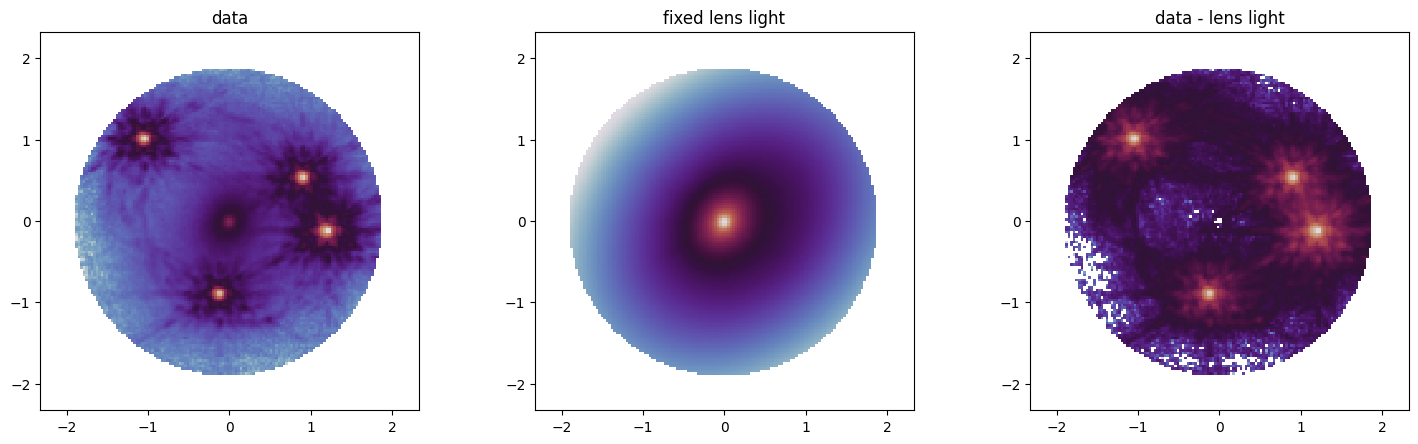

In [5]:
lens_light_image = np.array(data - data_subtracted, dtype=float)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(np.ma.array(data, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[0].set_title('data')
ax[1].imshow(np.ma.array(lens_light_image, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[1].set_title('fixed lens light')
ax[2].imshow(np.ma.array(data_subtracted, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
ax[2].set_title('data - lens light')
plt.tight_layout()
plt.show()


In [6]:
epl_mass_model = MassModel(['EPL'])
star_nfw_mass_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA', 'CUSPY_NFW_ELLIPSE_KAPPA'])

SIS_PRIORS = {
    'g1': {
        'plate_name': 'Lens mass g1',
        'param_name': 'g1',
        'origin': G1_MASS_CENTER,
        'theta_low': 0.0,
        'theta_high': 0.25,
    },
    'g2': {
        'plate_name': 'Lens mass g2',
        'param_name': 'g2',
        'origin': G2_MASS_CENTER,
        'theta_mean': 0.622,
        'theta_low': 0.5,
        'theta_high': 0.7,
    },
    'g3': {
        'origin': G3_MASS_CENTER,
        'theta_mean': 0.088,
    },
    'g7': {
        'origin': G7_MASS_CENTER,
        'theta_mean': 0.388,
    },
}


FIXED_SIS_THETA_E = {
    'g1': float(np.asarray(HMC_reference['theta_E_g1'].values).reshape(-1)[0]),
    'g2': float(np.asarray(HMC_reference['theta_E_g2'].values).reshape(-1)[0]),
}


def target_epl_kwargs_for_chain(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    e_i = np.asarray(chain_array('e_1', i), dtype=float).reshape(2, -1)
    return [{
        'theta_E': float(np.asarray(chain_array('theta_E_1', i)).reshape(-1)[0]),
        'gamma': float(np.asarray(chain_array('gamma_1', i)).reshape(-1)[0]),
        'e1': float(e_i[0, 0]),
        'e2': float(e_i[1, 0]),
        'center_x': float(center_i[0]),
        'center_y': float(center_i[1]),
    }]


def scaled_mass_from_light(m2l_ratio):
    mass_from_light = deepcopy(full_lens_light)
    amp = jnp.asarray(mass_from_light[0]['amp'])
    mass_from_light[0]['amp'] = amp * jnp.asarray(m2l_ratio, dtype=jnp.float64) / jnp.sum(amp)
    return mass_from_light


def build_star_nfw_kwargs_ls(m2l_ratio, kappa_s_halo, e1_halo, e2_halo, center_i):
    mass_from_light = scaled_mass_from_light(m2l_ratio)
    halo = {
        'R_s': 5.0,
        'gamma': 1.0,
        'kappa_s': float(kappa_s_halo),
        'e1': float(e1_halo),
        'e2': float(e2_halo),
        'center_x': float(center_i[0]),
        'center_y': float(center_i[1]),
    }
    return mass_from_light + [halo]


def build_step6_mass_init(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    target_epl_kwargs_i = target_epl_kwargs_for_chain(i)
    target_epl_kappa_i = np.array(epl_mass_model.kappa(xgrid, ygrid, target_epl_kwargs_i), dtype=float)

    def ls_residual(theta):
        model_kappa = np.array(
            star_nfw_mass_model.kappa(
                xgrid,
                ygrid,
                build_star_nfw_kwargs_ls(theta[0], theta[1], theta[2], theta[3], center_i),
            ),
            dtype=float,
        )
        return (model_kappa - target_epl_kappa_i)[mask_out].ravel()

    ls_x0 = np.array([
        2.0,
        0.1,
        target_epl_kwargs_i[0]['e1'],
        target_epl_kwargs_i[0]['e2'],
    ], dtype=float)
    ls_result = least_squares(
        ls_residual,
        x0=ls_x0,
        bounds=([0.0, 0.0, -0.2, -0.2], [14.0, 1.0, 0.2, 0.2]),
    )
    init_i = {
        'm2l_ratio': jnp.asarray(ls_result.x[0], dtype=jnp.float64),
        'kappa_s_halo': jnp.asarray(ls_result.x[1], dtype=jnp.float64),
        'gammain_halo': jnp.asarray(1.0, dtype=jnp.float64),
        'e_halo': jnp.asarray(ls_result.x[2:4], dtype=jnp.float64),
    }
    return init_i, ls_result


STEP6_MASS_INITS = []
STEP6_LS_RESULTS = []
for i in range(num_chains):
    init_i, ls_result_i = build_step6_mass_init(i)
    STEP6_MASS_INITS.append(init_i)
    STEP6_LS_RESULTS.append(ls_result_i)
    print(
        f'chain {i}: '
        f'm2l_ratio={float(ls_result_i.x[0]):.4f}, '
        f'kappa_s_halo={float(ls_result_i.x[1]):.4f}, '
        f'e1={float(ls_result_i.x[2]):.4f}, '
        f'e2={float(ls_result_i.x[3]):.4f}, '
        f'success={bool(ls_result_i.success)}, '
        f'cost={float(ls_result_i.cost):.4f}'
    )


STEP1_BASE_KWARGS = {
    'label': 'step1',
    'gnfw_kwargs': {
        'gamma_in_up': 1.4,
        'gamma_in_low': 0.6,
        'Rs_value': 5.0,
        'sph': False,
        'gamma_sheer_low': -0.5,
        'gamma_sheer_high': 0.5,
    },
    'fixed_sis_theta_E': FIXED_SIS_THETA_E,
    'free_sis': (),
    'scale_with_g2': True,
    'free_point_source': False,
    'use_conjugate_prior': False,
    'compute_fermat_diffs': False,
    'use_ml_gradient': False,
}


def build_step1_stage_kwargs(i):
    center_i = np.asarray(chain_array('center_1', i), dtype=float).reshape(2,)
    shear_i = np.asarray(chain_array('gamma_sheer_1', i), dtype=float).reshape(2,)
    return STEP1_BASE_KWARGS | {
        'gnfw_kwargs': STEP1_BASE_KWARGS['gnfw_kwargs'] | {
            'center_x': float(center_i[0]),
            'center_y': float(center_i[1]),
            'gamma_sheer_value': shear_i,
        }
    }


STEP2_KWARGS = {
    'label': 'step2',
    'gnfw_kwargs': {
        'gamma_in_up': 1.4,
        'gamma_in_low': 0.6,
        'Rs_low': 2,
        'Rs_high': 20.0,
        'sph': False,
        'gamma_sheer_low': -0.5,
        'gamma_sheer_high': 0.5,
    },
    'fixed_sis_theta_E': {},
    'free_sis': ('g1', 'g2'),
    'scale_with_g2': True,
    'free_point_source': True,
    'use_conjugate_prior': True,
    'compute_fermat_diffs': True,
    'use_ml_gradient': False,
}


chain 0: m2l_ratio=1.5051, kappa_s_halo=0.1831, e1=-0.0861, e2=0.0336, success=True, cost=88.0052
chain 1: m2l_ratio=1.4891, kappa_s_halo=0.1839, e1=-0.0868, e2=0.0351, success=True, cost=88.0763
chain 2: m2l_ratio=1.4530, kappa_s_halo=0.1728, e1=-0.1023, e2=0.0323, success=True, cost=95.9826
chain 3: m2l_ratio=1.4347, kappa_s_halo=0.1861, e1=-0.0886, e2=0.0398, success=True, cost=90.9635
chain 4: m2l_ratio=1.5106, kappa_s_halo=0.1784, e1=-0.0858, e2=0.0332, success=True, cost=88.2040
chain 5: m2l_ratio=1.5670, kappa_s_halo=0.1733, e1=-0.1173, e2=0.0378, success=True, cost=59.9854


In [7]:
def fixed_sis(theta_E, origin):
    return [{
        'theta_E': theta_E,
        'center_x': float(origin[0]),
        'center_y': float(origin[1]),
    }]

def build_stage_convergence(stage_kwargs):
    if stage_kwargs.get('use_time_delay_likelihood', False):
        kappa_ext = numpyro.sample(
            'kappa_ext',
            dist.Uniform(
                low=jnp.asarray(KAPPA_EXT_PRIOR['low'], dtype=jnp.float64),
                high=jnp.asarray(KAPPA_EXT_PRIOR['high'], dtype=jnp.float64),
            ),
        )
        numpyro.factor(
            'kappa_ext_prior',
            Numpyro_function.split_normal_logpdf(
                kappa_ext,
                KAPPA_EXT_PRIOR['mean'],
                KAPPA_EXT_PRIOR['sigma_minus'],
                KAPPA_EXT_PRIOR['sigma_plus'],
            ),
        )
        return [{
            'kappa': kappa_ext,
            'ra_0': jnp.asarray(0.0, dtype=jnp.float64),
            'dec_0': jnp.asarray(0.0, dtype=jnp.float64),
        }]
    return [{
        'kappa': jnp.asarray(0.0, dtype=jnp.float64),
        'ra_0': jnp.asarray(0.0, dtype=jnp.float64),
        'dec_0': jnp.asarray(0.0, dtype=jnp.float64),
    }]


def add_single_time_delay_likelihood(dt_name, like_name, prefactor_days, fpd, obs_key):
    dt = numpyro.deterministic(dt_name, prefactor_days * fpd)
    numpyro.factor(
        like_name,
        Numpyro_function.split_normal_logpdf(
            dt,
            TIME_DELAY_OBS[obs_key]['mean'],
            TIME_DELAY_OBS[obs_key]['sigma_minus'],
            TIME_DELAY_OBS[obs_key]['sigma_plus'],
        ),
    )
    return dt


def build_stage_sis(stage_kwargs):
    sis_mass = []
    fixed_sis_theta_E = dict(stage_kwargs['fixed_sis_theta_E'])

    if 'g1' in fixed_sis_theta_E:
        sis_mass += fixed_sis(fixed_sis_theta_E.pop('g1'), G1_MASS_CENTER)

    if 'g2' in fixed_sis_theta_E:
        theta_E_g2 = jnp.asarray(fixed_sis_theta_E.pop('g2'), dtype=jnp.float64)
        sis_mass += fixed_sis(theta_E_g2, G2_MASS_CENTER)
        if stage_kwargs['scale_with_g2']:
            theta_E_g3 = numpyro.deterministic(
                'theta_E_g3',
                Mass.scale_theta_E_from_g2(
                    theta_E_g2,
                    SIS_PRIORS['g3']['theta_mean'],
                    SIS_PRIORS['g2']['theta_mean'],
                ),
            )
            theta_E_g7 = numpyro.deterministic(
                'theta_E_g7',
                Mass.scale_theta_E_from_g2(
                    theta_E_g2,
                    SIS_PRIORS['g7']['theta_mean'],
                    SIS_PRIORS['g2']['theta_mean'],
                ),
            )
            sis_mass += fixed_sis(theta_E_g3, G3_MASS_CENTER)
            sis_mass += fixed_sis(theta_E_g7, G7_MASS_CENTER)

    for name, theta_E in fixed_sis_theta_E.items():
        sis_mass += fixed_sis(theta_E, SIS_PRIORS[name]['origin'])

    if 'g1' in stage_kwargs['free_sis']:
        sis_mass += Mass.SIS(**SIS_PRIORS['g1'])

    if 'g2' in stage_kwargs['free_sis']:
        g2_mass = Mass.SIS(**SIS_PRIORS['g2'])
        sis_mass += g2_mass
        if stage_kwargs['scale_with_g2']:
            theta_E_g2 = g2_mass[0]['theta_E']
            theta_E_g3 = numpyro.deterministic(
                'theta_E_g3',
                Mass.scale_theta_E_from_g2(
                    theta_E_g2,
                    SIS_PRIORS['g3']['theta_mean'],
                    SIS_PRIORS['g2']['theta_mean'],
                ),
            )
            theta_E_g7 = numpyro.deterministic(
                'theta_E_g7',
                Mass.scale_theta_E_from_g2(
                    theta_E_g2,
                    SIS_PRIORS['g7']['theta_mean'],
                    SIS_PRIORS['g2']['theta_mean'],
                ),
            )
            sis_mass += fixed_sis(theta_E_g3, G3_MASS_CENTER)
            sis_mass += fixed_sis(theta_E_g7, G7_MASS_CENTER)

    return sis_mass


def build_stage_point_source(stage_kwargs):
    if not stage_kwargs['free_point_source']:
        return fixed_point_source

    n_ps = conj_points.shape[0]
    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ),
    )
    log10_amp_ps = numpyro.sample(
        'log10_amp_ps',
        dist.Uniform(
            POINT_SOURCE_PRIOR['log10_amp_low'],
            POINT_SOURCE_PRIOR['log10_amp_high'],
        ).expand([n_ps]),
    )
    return [{
        'ra': ra_ps,
        'dec': dec_ps,
        'amp': jnp.power(10.0, log10_amp_ps),
    }]


def build_stage_psf():
    psf_kernel = jnp.asarray(fixed_psf)
    numpyro.deterministic('psf_kernel_corrected', psf_kernel)
    return psf_kernel


def maybe_add_conjugate_prior(stage_kwargs, kwargs_lens, kwargs_point_source):
    if not stage_kwargs['use_conjugate_prior']:
        return
    src_x_ps, src_y_ps = lens_image_step6.MassModel.ray_shooting(
        kwargs_point_source[0]['ra'],
        kwargs_point_source[0]['dec'],
        kwargs_lens,
    )
    conj_points_model = jnp.stack([src_x_ps, src_y_ps], axis=1)
    conj_distance = Geometry.reduced_distance_matrix(conj_points_model)
    nc = conj_distance.shape[0]
    with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
        numpyro.sample('conjugate_points', dist.Exponential(CONJUGATE_POINT_PRIOR['rate']), obs=conj_distance)




def gradient_mass_from_light(m2l_ratio, m2l_ratio_slope):
    mass_from_light = deepcopy(full_lens_light)
    sigma = jnp.asarray(mass_from_light[0]['sigma'], dtype=jnp.float64)
    amp = jnp.asarray(mass_from_light[0]['amp'], dtype=jnp.float64)
    R_factor = jnp.power(sigma, jnp.asarray(m2l_ratio_slope, dtype=jnp.float64))
    ml_gauss = numpyro.deterministic('ml_gauss', jnp.asarray(m2l_ratio, dtype=jnp.float64) * R_factor)
    mass_from_light[0]['amp'] = numpyro.deterministic(
        'mass_from_light_amp',
        amp / jnp.sum(amp) * ml_gauss,
    )
    numpyro.deterministic('total_stellar_mass', jnp.sum(mass_from_light[0]['amp']))
    return mass_from_light


def model_step6(data_subtracted, stage_kwargs):
    m2l_ratio = numpyro.sample('m2l_ratio', dist.Uniform(0.0, 3.0))
    if stage_kwargs.get('use_ml_gradient', False):
        m2l_ratio_slope = numpyro.sample(
            'm2l_ratio_slope',
            dist.Uniform(
                stage_kwargs['m2l_ratio_slope_low'],
                stage_kwargs['m2l_ratio_slope_high'],
            ),
        )
        mass_from_light = gradient_mass_from_light(m2l_ratio, m2l_ratio_slope)
    else:
        mass_from_light = scaled_mass_from_light(m2l_ratio)

    gnfw_shear = Mass.GNFW_w_shear(
        'Lens mass',
        'halo',
        **stage_kwargs['gnfw_kwargs'],
    )
    kwargs_source = [
        PowerSpectrum.matern_power_spectrum(
            k=k_values,
            **SOURCE_GRID_PRIOR,
        )
    ]
    kwargs_lens = mass_from_light + gnfw_shear + build_stage_sis(stage_kwargs) + build_stage_convergence(stage_kwargs)
    kwargs_point_source = build_stage_point_source(stage_kwargs)
    maybe_add_conjugate_prior(stage_kwargs, kwargs_lens, kwargs_point_source)

    if stage_kwargs['compute_fermat_diffs']:
        fermat = lens_image_step6.MassModel.fermat_potential(
            kwargs_point_source[0]['ra'],
            kwargs_point_source[0]['dec'],
            kwargs_lens,
        )
        numpyro.deterministic('fermat_potential_images', fermat)
        fpd_31 = numpyro.deterministic('fpd_31', fermat[2] - fermat[0])
        fpd_32 = numpyro.deterministic('fpd_32', fermat[2] - fermat[1])
        fpd_34 = numpyro.deterministic('fpd_34', fermat[2] - fermat[3])

        if stage_kwargs.get('use_time_delay_likelihood', False):
            cosmology = Cosmo.sample_cosmology_from_prior(stage_kwargs, COSMO_PRIORS)
            D_dt = Cosmo.compute_time_delay_distances(
                cosmology,
                Z_LENS,
                Z_SOURCE,
            )
            numpyro.deterministic('D_dt_Mpc', D_dt)
            prefactor_days = numpyro.deterministic(
                'time_delay_prefactor_days',
                D_dt * jnp.asarray(TIME_DELAY_SCALE_DAYS, dtype=jnp.float64),
            )
            add_single_time_delay_likelihood('dt_31_days', 'dt_31_like', prefactor_days, fpd_31, 'dt_31_days')
            add_single_time_delay_likelihood('dt_32_days', 'dt_32_like', prefactor_days, fpd_32, 'dt_32_days')
            add_single_time_delay_likelihood('dt_34_days', 'dt_34_like', prefactor_days, fpd_34, 'dt_34_days')

    psf_kernel = build_stage_psf()

    model_image = lens_image_step6.model(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
        kwargs_lens_light=[],
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        lens_light_add=False,
        point_source_add=True,
    )
    numpyro.deterministic('model_image', model_image)

    with numpyro.plate(f'data - [{int(mask_out.sum())}]', int(mask_out.sum())):
        numpyro.sample('obs', dist.Normal(model_image[mask_out], jnp.asarray(rms_file)[mask_out]), obs=jnp.asarray(data_subtracted)[mask_out])


def evaluate_step6(params, stage_kwargs):
    def render_components(data_subtracted, stage_kwargs):
        m2l_ratio = numpyro.sample('m2l_ratio', dist.Uniform(0.0, 3.0))
        if stage_kwargs.get('use_ml_gradient', False):
            m2l_ratio_slope = numpyro.sample(
                'm2l_ratio_slope',
                dist.Uniform(
                    stage_kwargs['m2l_ratio_slope_low'],
                    stage_kwargs['m2l_ratio_slope_high'],
                ),
            )
            mass_from_light = gradient_mass_from_light(m2l_ratio, m2l_ratio_slope)
        else:
            mass_from_light = scaled_mass_from_light(m2l_ratio)

        gnfw_shear = Mass.GNFW_w_shear(
            'Lens mass',
            'halo',
            **stage_kwargs['gnfw_kwargs'],
        )
        kwargs_source = [
            PowerSpectrum.matern_power_spectrum(
                k=k_values,
                **SOURCE_GRID_PRIOR,
            )
        ]
        kwargs_lens = mass_from_light + gnfw_shear + build_stage_sis(stage_kwargs) + build_stage_convergence(stage_kwargs)
        kwargs_point_source = build_stage_point_source(stage_kwargs)
        return kwargs_lens, kwargs_source, kwargs_point_source

    seeded = numpyro.handlers.seed(model_step6, jax.random.PRNGKey(0))
    substituted = numpyro.handlers.substitute(seeded, data=params)
    trace = numpyro.handlers.trace(substituted).get_trace(data_subtracted, stage_kwargs)
    render_seeded = numpyro.handlers.seed(render_components, jax.random.PRNGKey(0))
    render_substituted = numpyro.handlers.substitute(render_seeded, data=params)
    kwargs_lens, kwargs_source, kwargs_point_source = render_substituted(data_subtracted, stage_kwargs)
    lensed_source_only = lens_image_step6.model(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
        kwargs_lens_light=[],
        kwargs_point_source=kwargs_point_source,
        source_add=True,
        lens_light_add=False,
        point_source_add=False,
    )
    fermat_diffs = None
    if stage_kwargs['compute_fermat_diffs']:
        fermat_diffs = {
            'fpd_31': float(np.asarray(trace['fpd_31']['value'])),
            'fpd_32': float(np.asarray(trace['fpd_32']['value'])),
            'fpd_34': float(np.asarray(trace['fpd_34']['value'])),
        }
        if stage_kwargs.get('use_time_delay_likelihood', False):
            extra_keys = [
                'omega_m_cosmo',
                'H0_cosmo',
                'kappa_ext',
                'D_dt_Mpc',
                'dt_31_days',
                'dt_32_days',
                'dt_34_days',
            ]
            for key in extra_keys:
                fermat_diffs[key] = float(np.asarray(trace[key]['value']))
    return (
        np.array(trace['model_image']['value']),
        np.array(lensed_source_only),
        np.array(trace['pixels_source_grid']['value']),
        np.array(trace['psf_kernel_corrected']['value']),
        fermat_diffs,
    )


def build_source_init_values(i):
    return {
        'n_source_grid': jnp.asarray(chain_array('n_source_grid', i), dtype=jnp.float64),
        'sigma_source_grid': jnp.asarray(chain_array('sigma_source_grid', i), dtype=jnp.float64),
        'rho_source_grid': jnp.asarray(chain_array('rho_source_grid', i), dtype=jnp.float64),
        'pixels_wn_source_grid': jnp.asarray(chain_array('pixels_wn_source_grid', i), dtype=jnp.float64),
    }


STEP1_LATENT_KEYS = (
    'm2l_ratio',
    'kappa_s_halo',
    'gammain_halo',
    'e_halo',
    'n_source_grid',
    'sigma_source_grid',
    'rho_source_grid',
    'pixels_wn_source_grid',
)

STEP2_LATENT_KEYS = STEP1_LATENT_KEYS + (
    'Rs_halo',
    'center_halo',
    'gamma_sheer_halo',
    'theta_E_g1',
    'theta_E_g2',
    'ra_ps',
    'dec_ps',
    'log10_amp_ps',
)

def build_step1_init_values(i):
    return build_source_init_values(i) | STEP6_MASS_INITS[i]


def build_step2_extra_init(i):
    return {
        'Rs_halo': jnp.asarray(5.0, dtype=jnp.float64),
        'center_halo': jnp.asarray(chain_array('center_1', i), dtype=jnp.float64).reshape(2,),
        'gamma_sheer_halo': jnp.asarray(chain_array('gamma_sheer_1', i), dtype=jnp.float64).reshape(2,),
        'theta_E_g1': jnp.asarray(chain_array('theta_E_g1', i), dtype=jnp.float64),
        'theta_E_g2': jnp.asarray(chain_array('theta_E_g2', i), dtype=jnp.float64),
        'ra_ps': jnp.asarray(chain_array('ra_ps', i), dtype=jnp.float64),
        'dec_ps': jnp.asarray(chain_array('dec_ps', i), dtype=jnp.float64),
        'log10_amp_ps': jnp.asarray(chain_array('log10_amp_ps', i), dtype=jnp.float64),
    }

def run_stage(stage_kwargs_or_builder, init_builder, max_iterations, seed):
    scheduler = optax.exponential_decay(init_value=5e-3, transition_steps=300, decay_rate=0.99)
    optim = optax.adabelief(learning_rate=scheduler)
    loss = infer.TraceMeanField_ELBO()

    rng = jax.random.PRNGKey(seed)
    keys = jax.random.split(rng, num_chains)
    results = []
    medians = []
    stage_kwargs_list = []
    init_values_list = []
    guide_params_list = []

    for i in range(num_chains):
        stage_kwargs_i = stage_kwargs_or_builder(i) if callable(stage_kwargs_or_builder) else stage_kwargs_or_builder
        init_values = init_builder(i)
        init_fun = ResumeInit.init_to_value_or_defer(values=init_values)
        guide = autoguide.AutoDiagonalNormal(model_step6, init_loc_fn=init_fun, init_scale=0.01)
        svi = infer.SVI(model_step6, guide, optim, loss)
        result = svi.run(keys[i], max_iterations, data_subtracted, stage_kwargs_i, progress_bar=True, stable_update=True)
        results.append(result)
        medians.append(guide.median(result.params))
        stage_kwargs_list.append(stage_kwargs_i)
        init_values_list.append(init_values)
        guide_params_list.append(result.params)

    multi_results = jax.tree.map(ResumeInit.stack_or_none, *results)
    return {
        'label': stage_kwargs_list[0]['label'],
        'results': results,
        'multi_results': multi_results,
        'medians': medians,
        'stage_kwargs_list': stage_kwargs_list,
        'init_values_list': init_values_list,
        'guide_params_list': guide_params_list,
        'max_iterations': max_iterations,
    }


def plot_stage_losses(stage_output, output_dir=None):
    fig, ax = plt.subplots(figsize=(15, 3.5))
    axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])
    for losses in stage_output['multi_results'].losses:
        _ = Plot.plot_loss(losses, stage_output['max_iterations'], ax=ax, axins=axins, alpha=0.25)
    fig.tight_layout()
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{Plot.sanitize_label(stage_output['label'])}_loss.png"
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f"Saved stage loss figure: {out_path}")
    plt.show()


def plot_stage_results(stage_output, output_dir=None):
    for i, params in enumerate(stage_output['medians']):
        stage_kwargs_i = stage_output['stage_kwargs_list'][i]
        model_image, lensed_source_only, source_pixels, psf_kernel, fermat_diffs = evaluate_step6(params, stage_kwargs_i)
        residual = (data_subtracted - model_image) / rms_file

        title = (
            f"{stage_output['label']} | chain {i} | M/L = {float(np.asarray(params['m2l_ratio']).reshape(-1)[0]):.3f} | "
            f"kappa_s = {float(np.asarray(params['kappa_s_halo']).reshape(-1)[0]):.4f} | "
            f"gamma = {float(np.asarray(params['gammain_halo']).reshape(-1)[0]):.4f}"
        )
        if stage_kwargs_i.get('use_ml_gradient', False) and 'm2l_ratio_slope' in params:
            title += f" | M/L slope = {float(np.asarray(params['m2l_ratio_slope']).reshape(-1)[0]):.4f}"
        if fermat_diffs is not None:
            title += (
                f" | φ3-1 = {fermat_diffs['fpd_31']:.4f}"
                f" | φ3-2 = {fermat_diffs['fpd_32']:.4f}"
                f" | φ3-4 = {fermat_diffs['fpd_34']:.4f}"
            )
            if stage_kwargs_i.get('use_time_delay_likelihood', False):
                title += (
                    f" | Ωm = {fermat_diffs['omega_m_cosmo']:.4f}"
                    f" | H0 = {fermat_diffs['H0_cosmo']:.2f}"
                    f" | κext = {fermat_diffs['kappa_ext']:.3f}"
                    f" | Δt31 = {fermat_diffs['dt_31_days']:.2f} d"
                    f" | Δt32 = {fermat_diffs['dt_32_days']:.2f} d"
                    f" | Δt34 = {fermat_diffs['dt_34_days']:.2f} d"
                )

        fig, ax = plt.subplots(1, 5, figsize=(22.5, 4.5))
        fig.suptitle(title, y=1.02)

        ax[0].imshow(np.ma.array(data_subtracted, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
        ax[0].set_title('data - lens light')

        ax[1].imshow(np.ma.array(model_image, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
        ax[1].set_title('model')

        ax[2].imshow(np.ma.array(lensed_source_only, mask=~mask_out), origin='lower', extent=extent, cmap='twilight', norm='log')
        ax[2].set_title('lensed source only')

        im = ax[3].imshow(np.ma.array(residual, mask=~mask_out), origin='lower', extent=extent, cmap='bwr', vmin=-3, vmax=3)
        ax[3].set_title('residual / rms')
        plt.colorbar(im, ax=ax[3], fraction=0.046, pad=0.04)

        ax[4].imshow(source_pixels, origin='lower', cmap='twilight')
        ax[4].set_title('source')

        plt.tight_layout()
        if output_dir is not None:
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            out_path = output_dir / f"{Plot.sanitize_label(stage_output['label'])}_chain_{i:02d}.png"
            fig.savefig(out_path, dpi=180, bbox_inches='tight')
            print(f"Saved stage result figure: {out_path}")
        plt.show()


100%|██████████| 20000/20000 [01:13<00:00, 271.97it/s, init loss: 31486.3579, avg. loss [19001-20000]: -20305.1061]


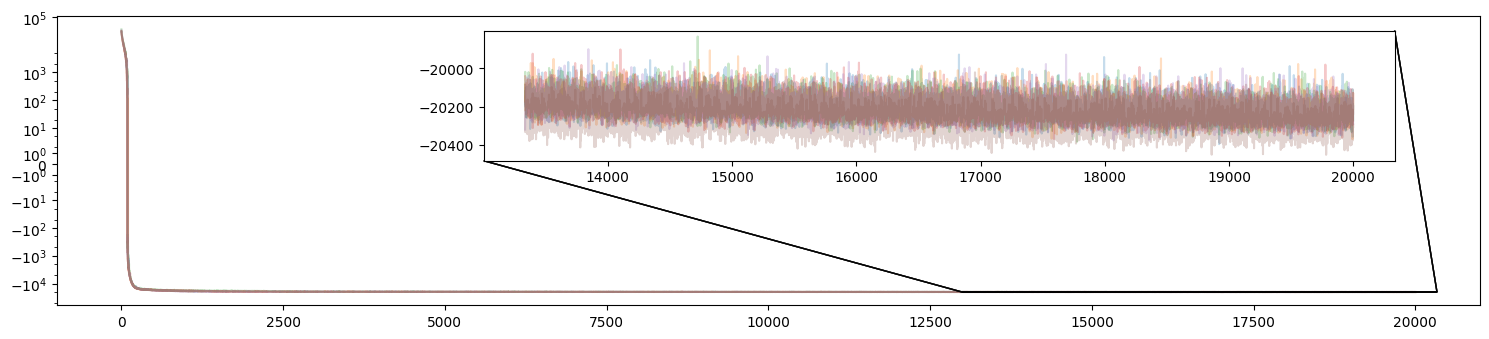

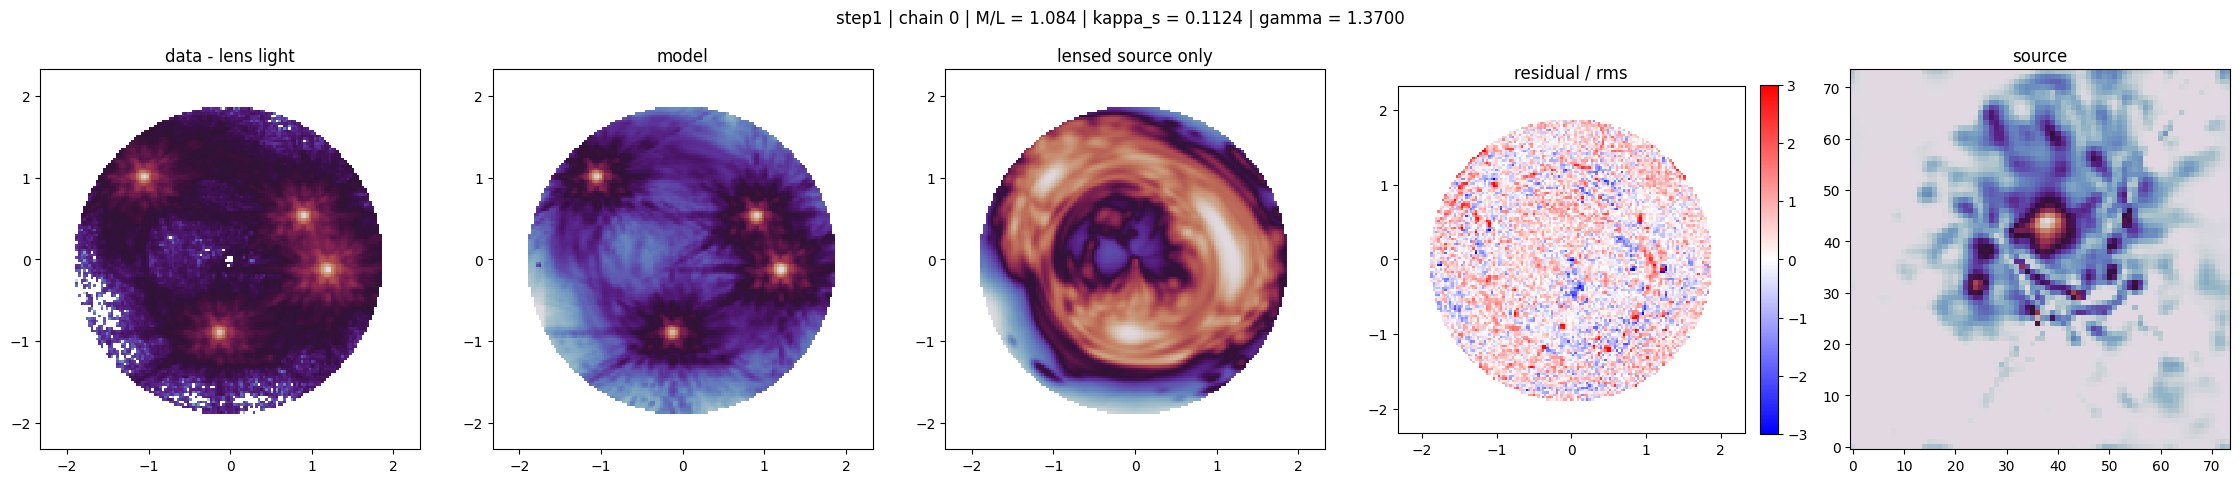

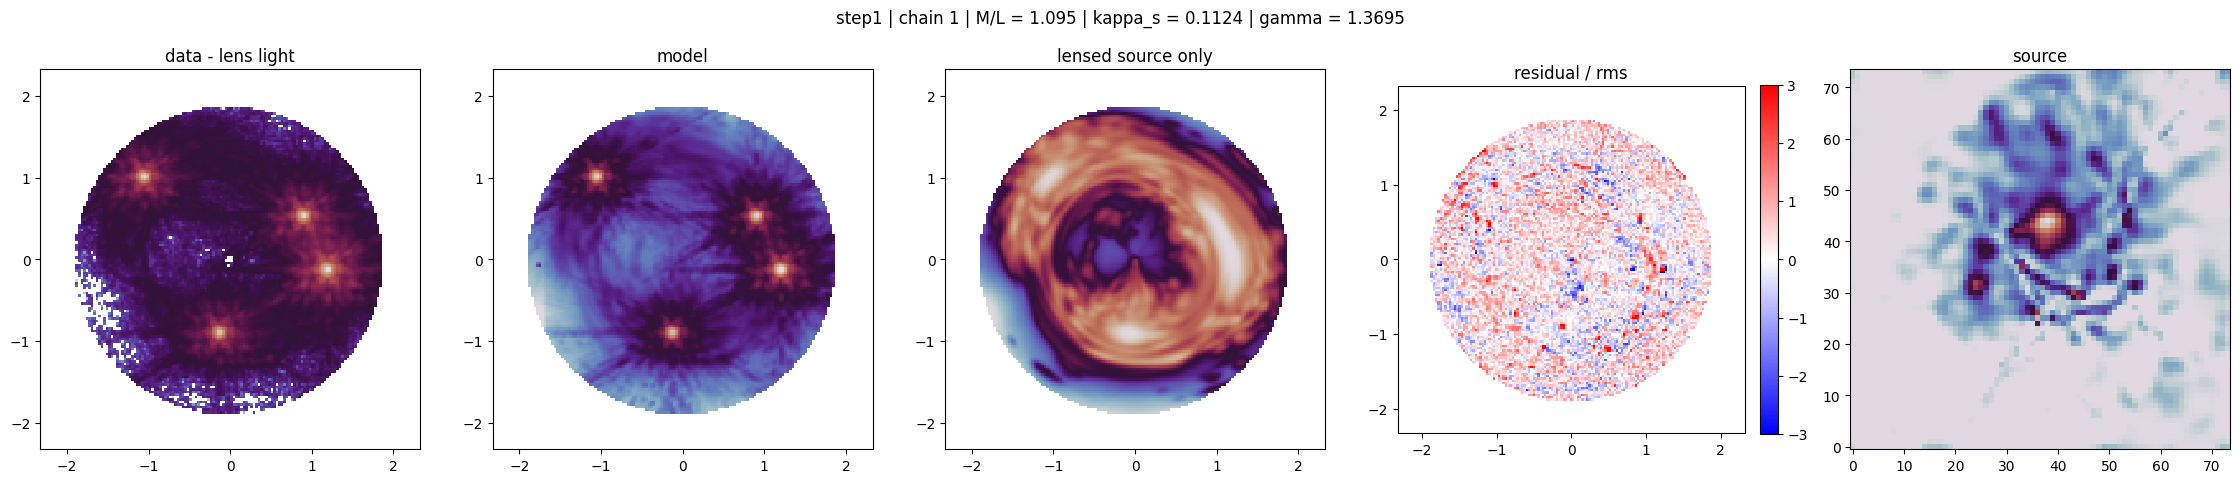

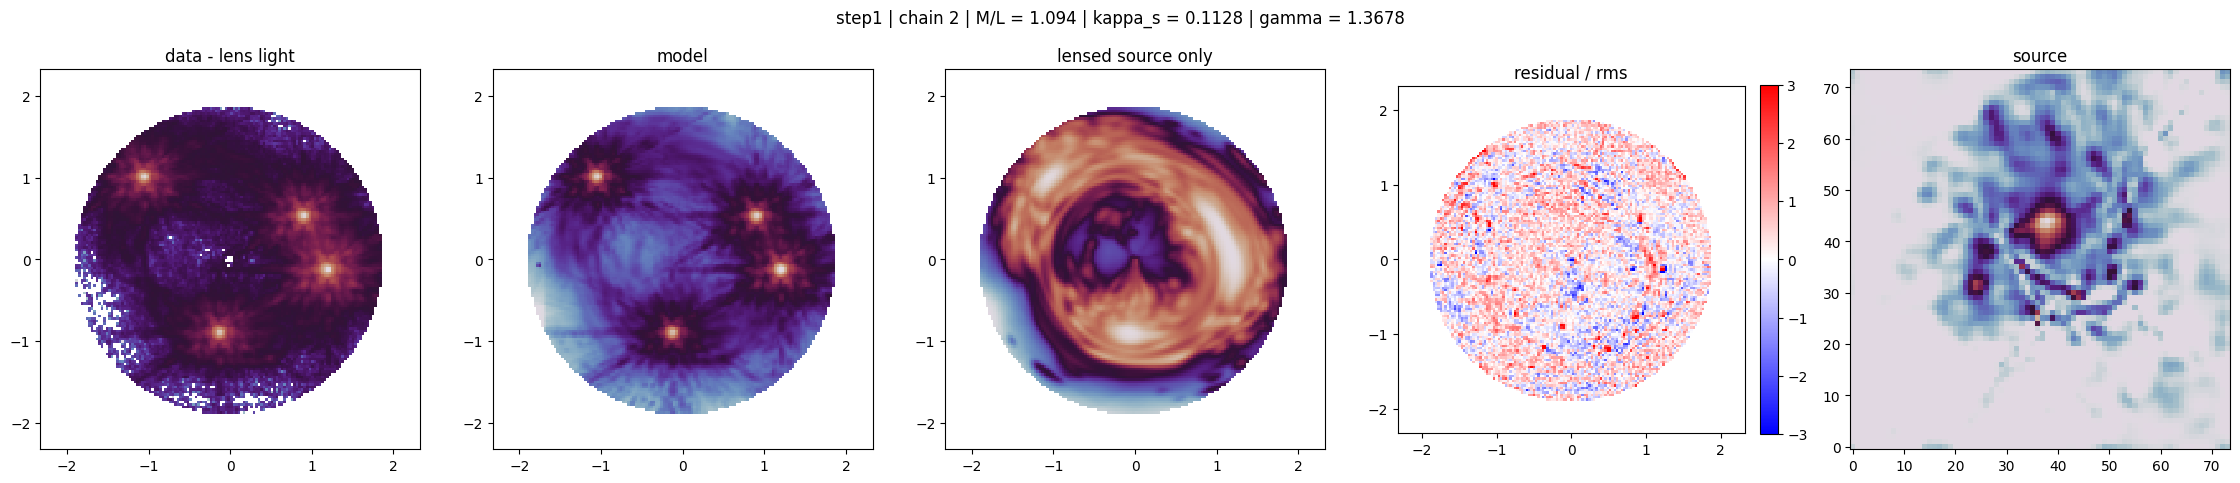

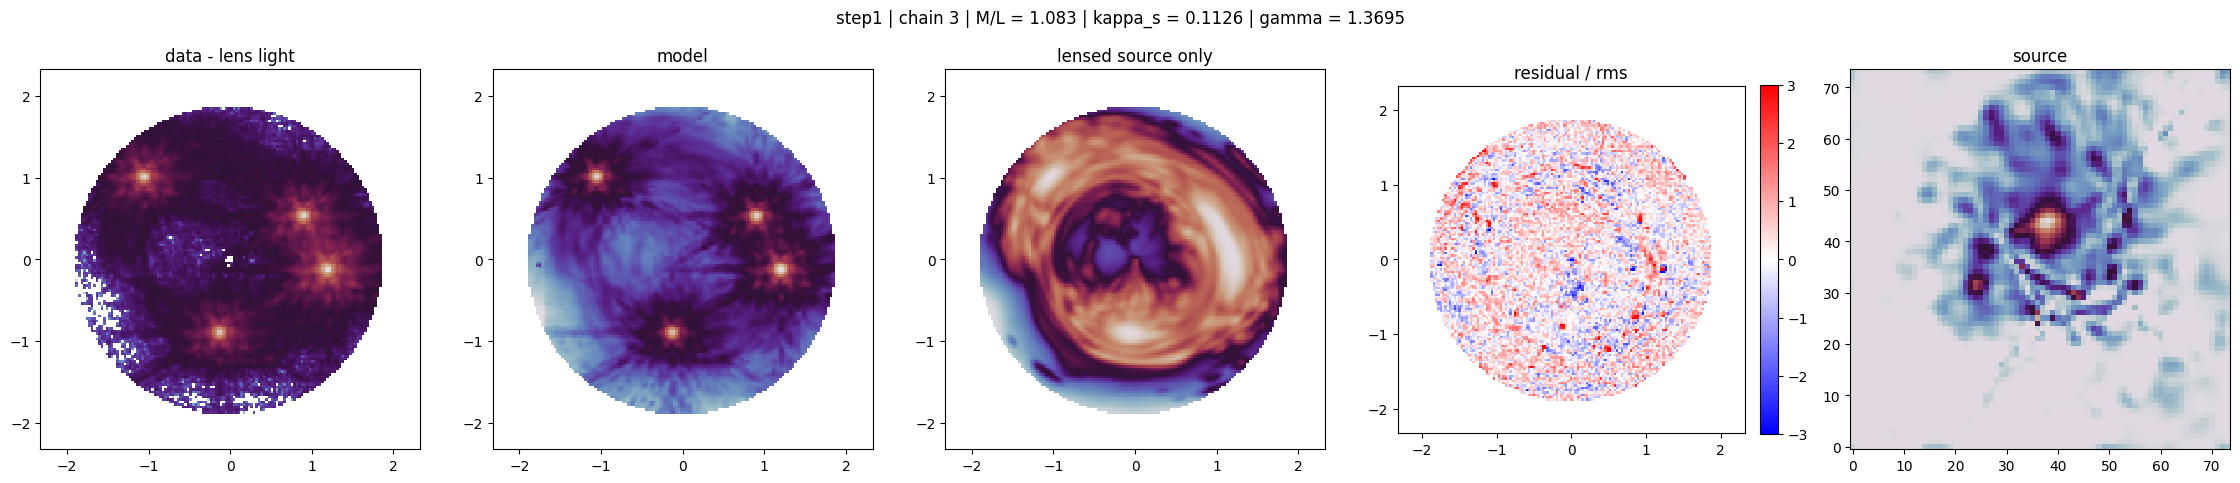

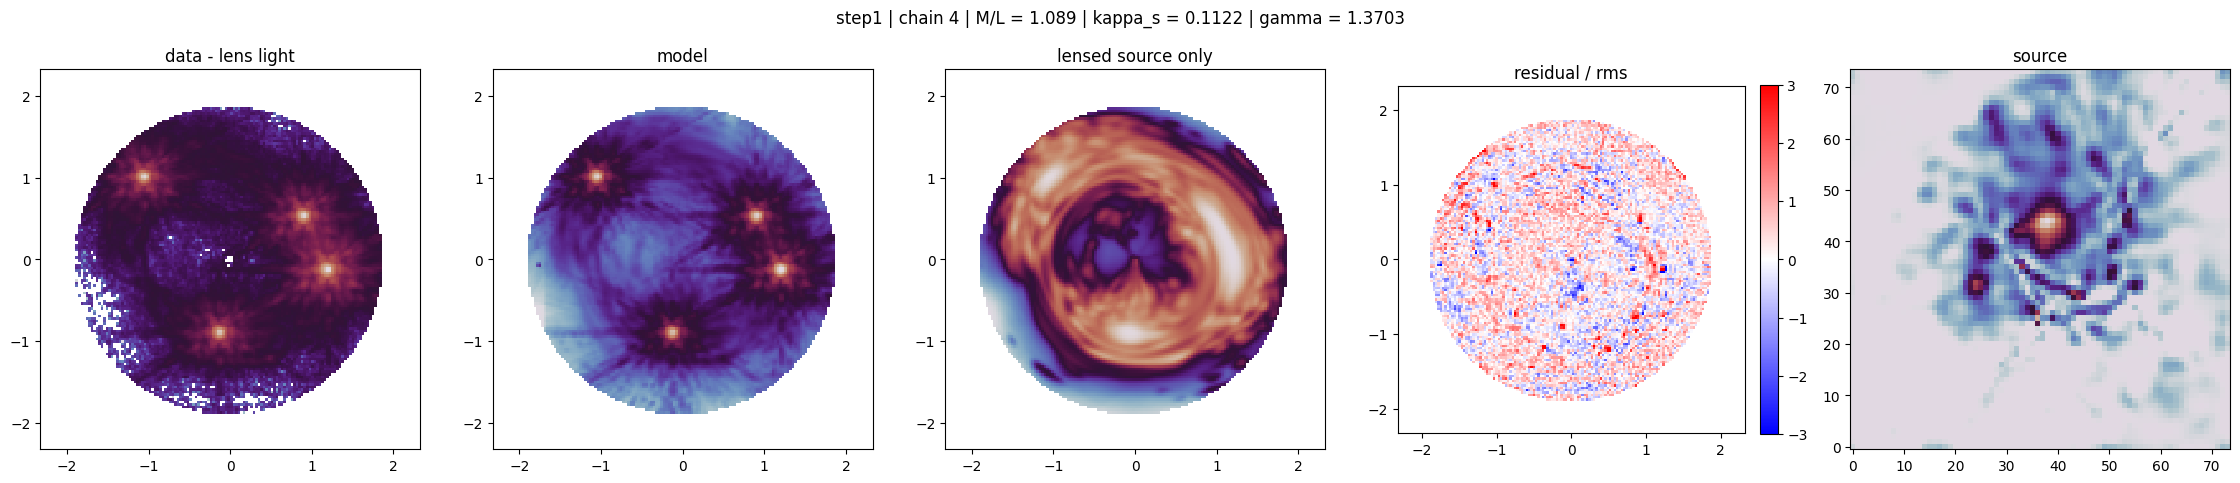

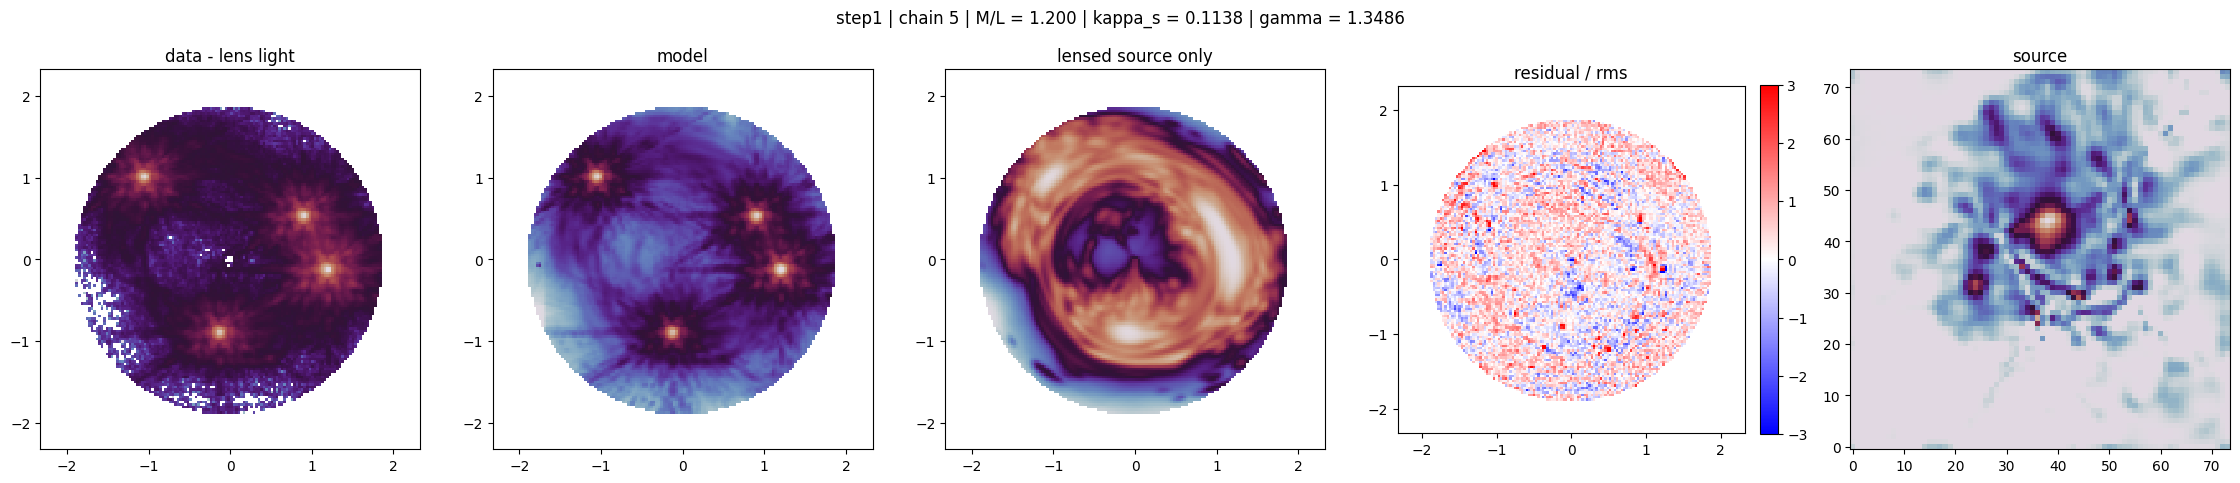

In [8]:
step1_output = run_stage(
    build_step1_stage_kwargs,
    init_builder=build_step1_init_values,
    max_iterations=20000,
    seed=1234,
)

plot_stage_losses(step1_output)
plot_stage_results(step1_output)


100%|██████████| 20000/20000 [01:28<00:00, 225.71it/s, init loss: 7136.3848, avg. loss [19001-20000]: -20556.5284]


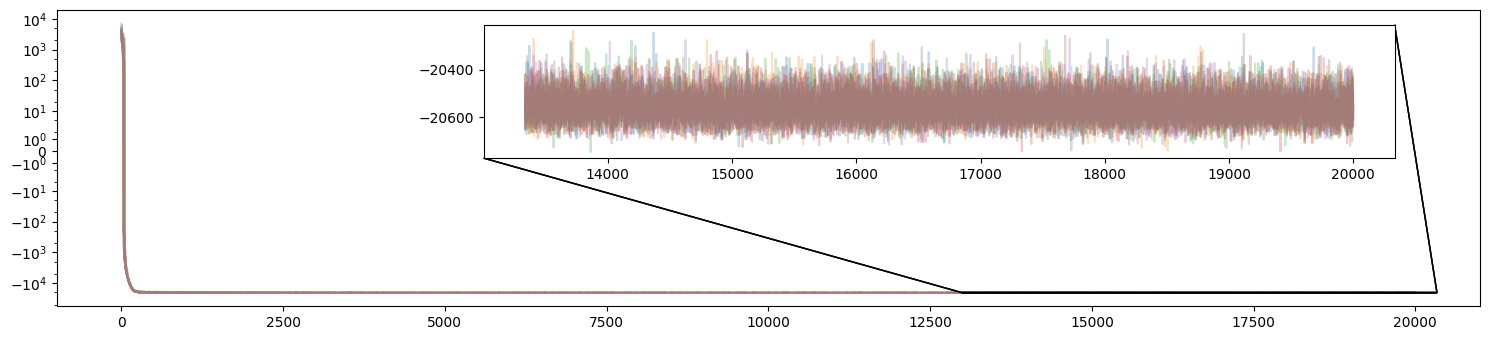

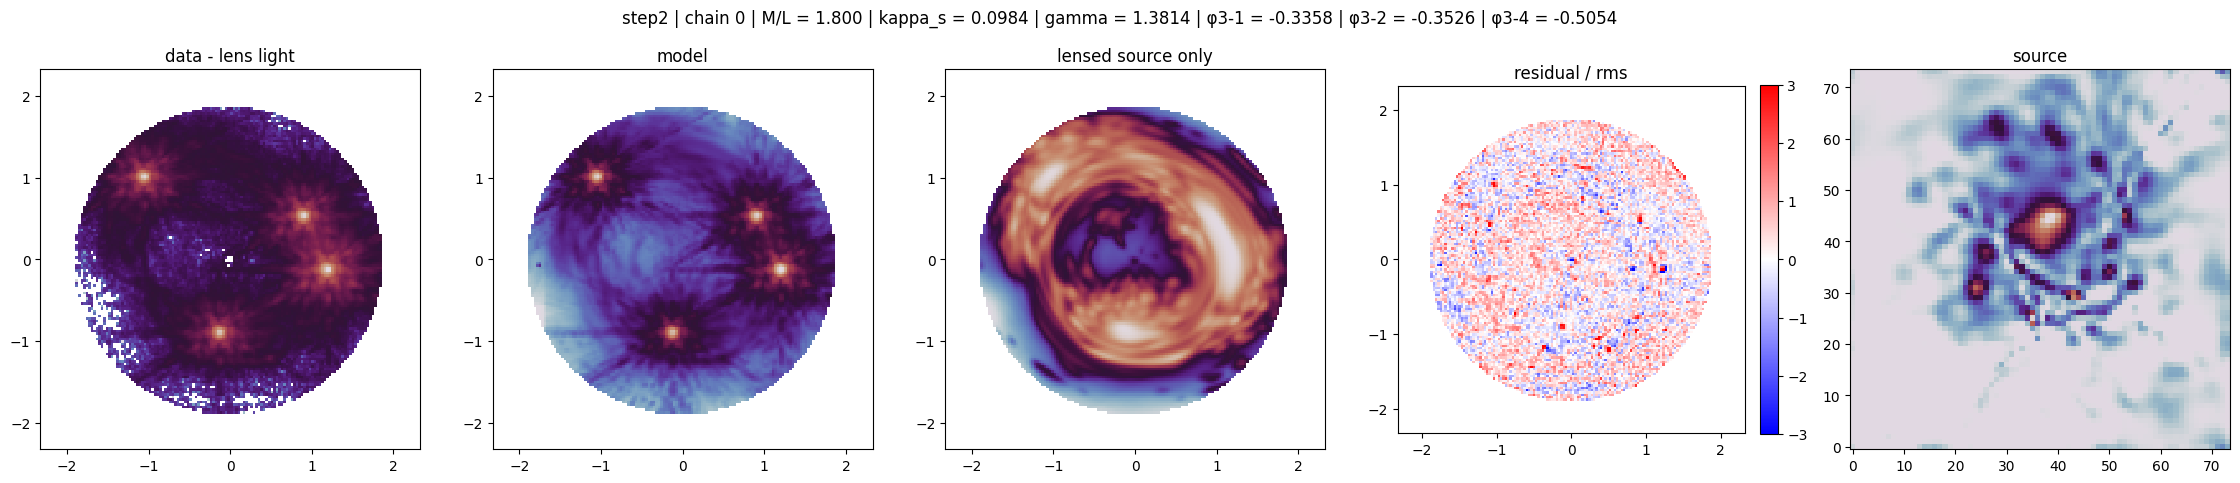

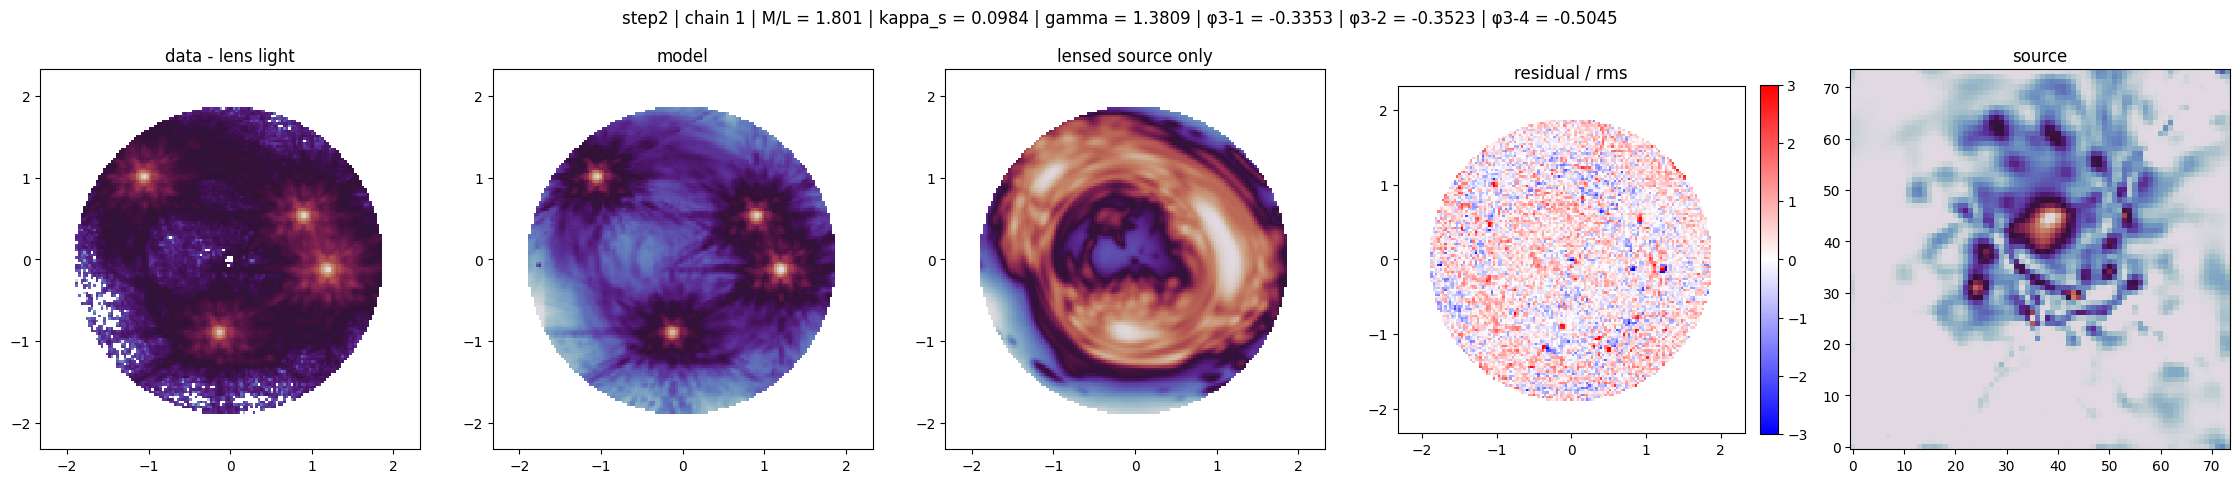

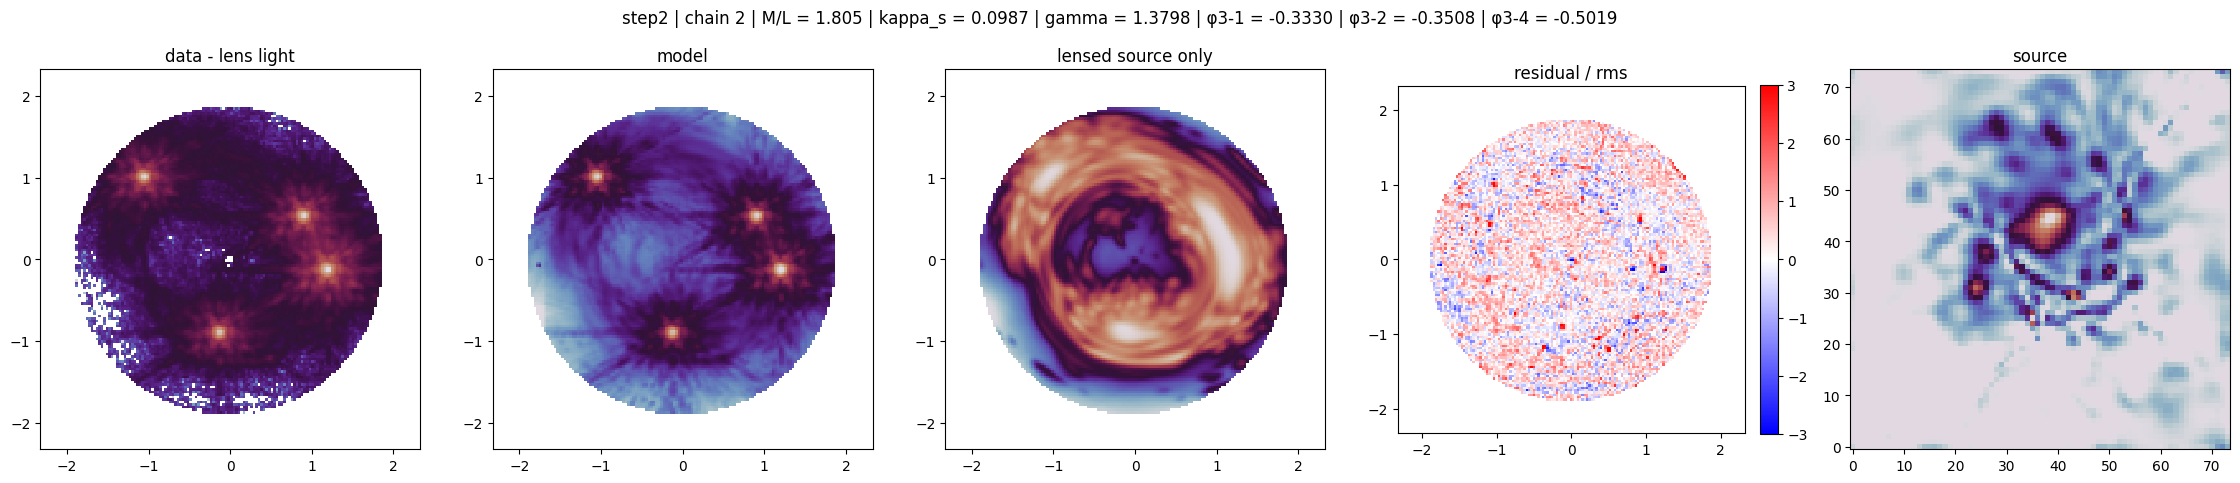

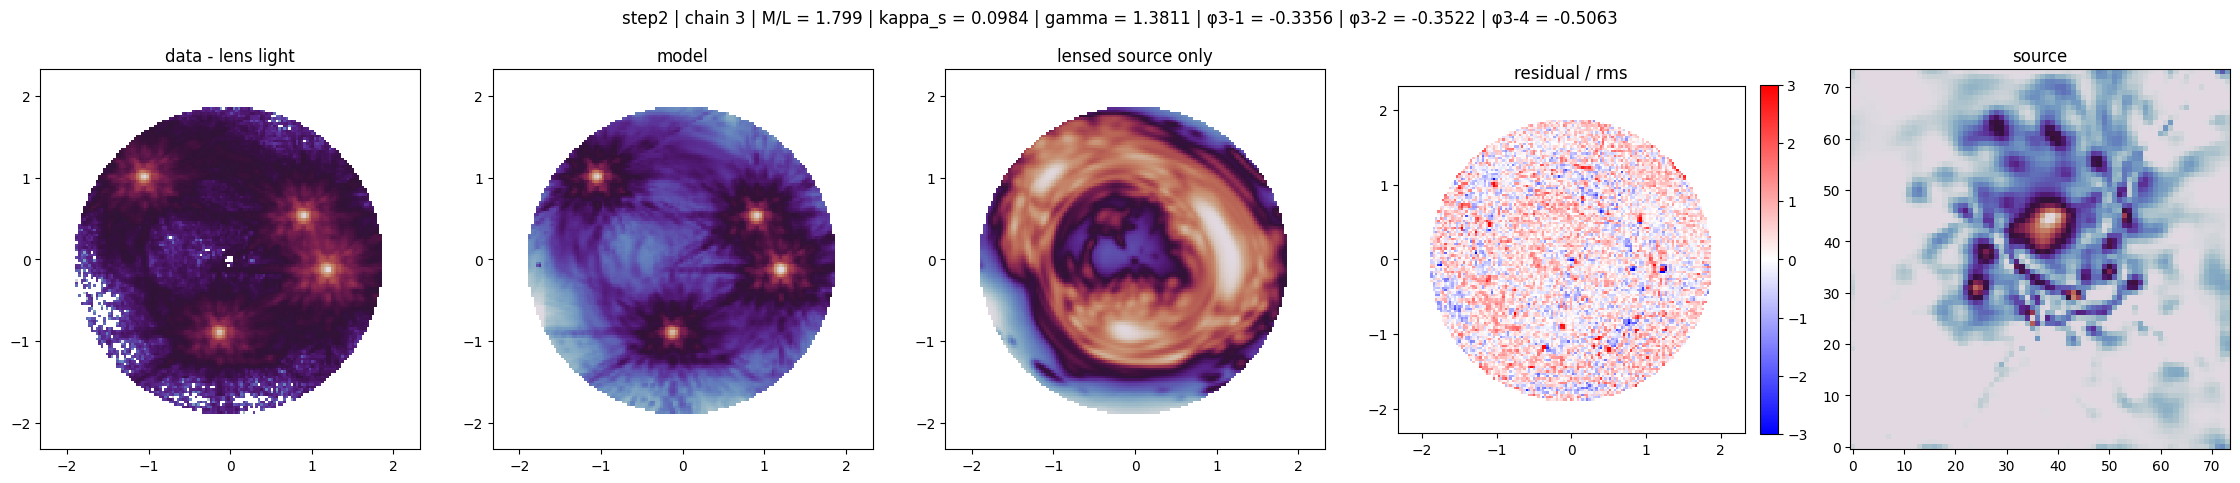

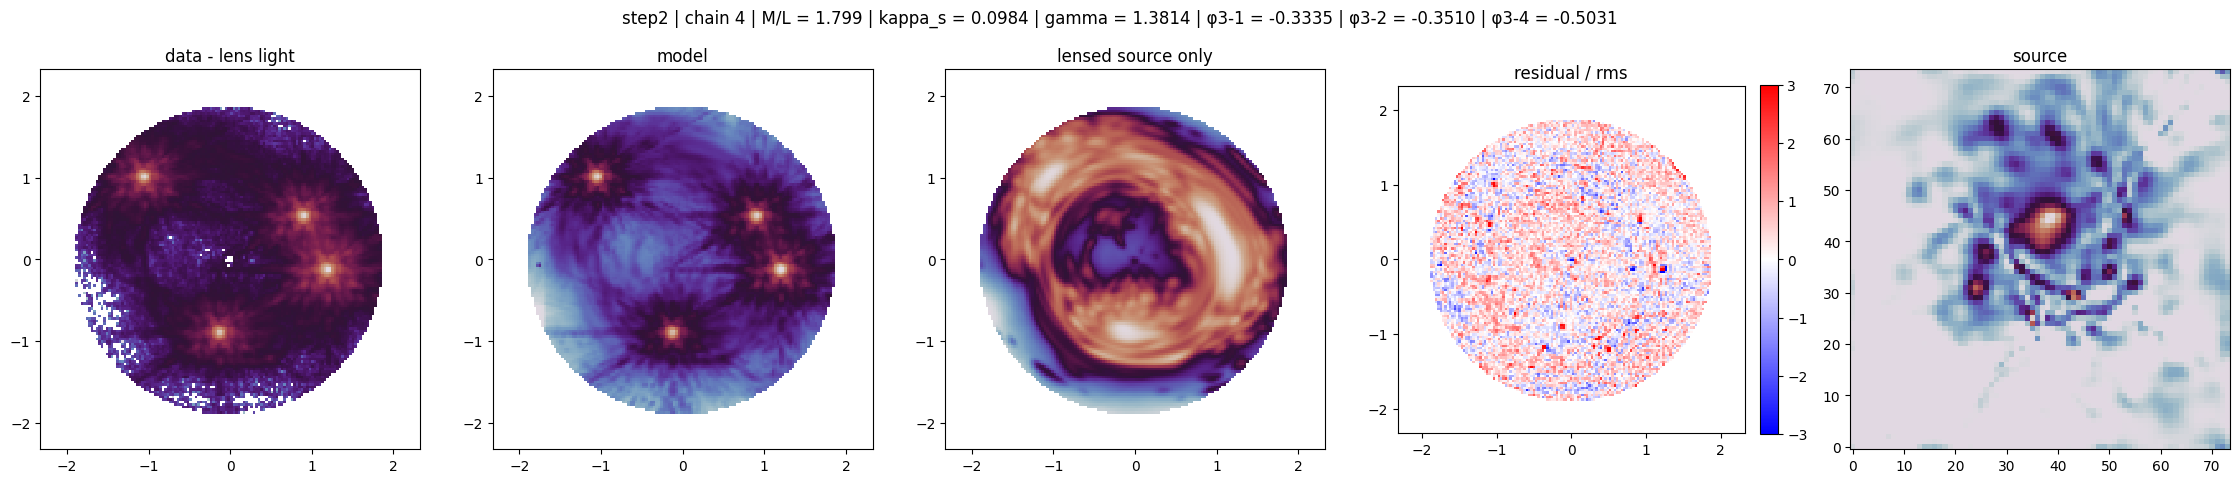

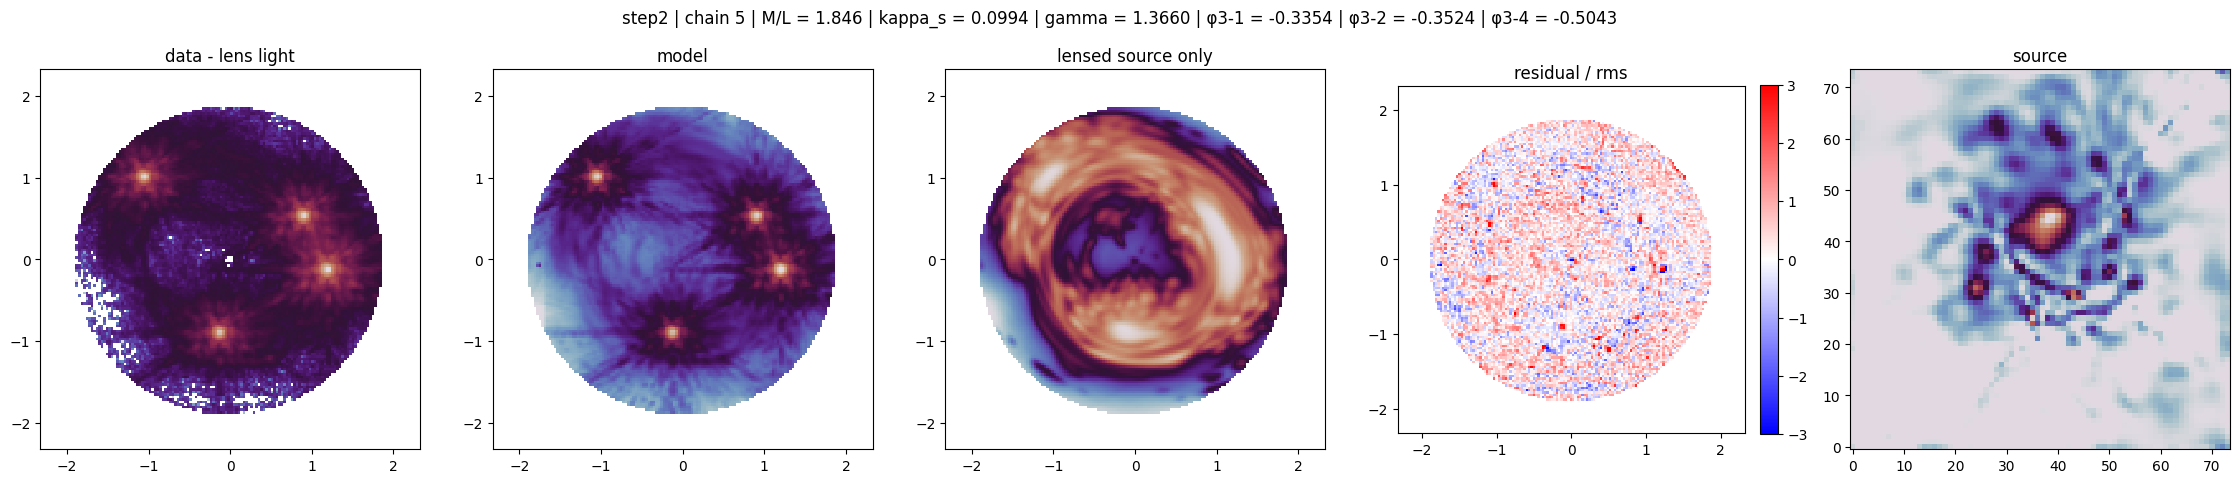

In [9]:
def build_step2_init_values(i):
    return ResumeInit.select_init_values(step1_output['medians'][i], STEP1_LATENT_KEYS) | build_step2_extra_init(i)


step2_output = run_stage(
    STEP2_KWARGS,
    init_builder=build_step2_init_values,
    max_iterations=20000,
    seed=2234,
)

plot_stage_losses(step2_output)
plot_stage_results(step2_output)


100%|██████████| 20000/20000 [01:47<00:00, 186.40it/s, init loss: 15692.2527, avg. loss [19001-20000]: -20572.4025]


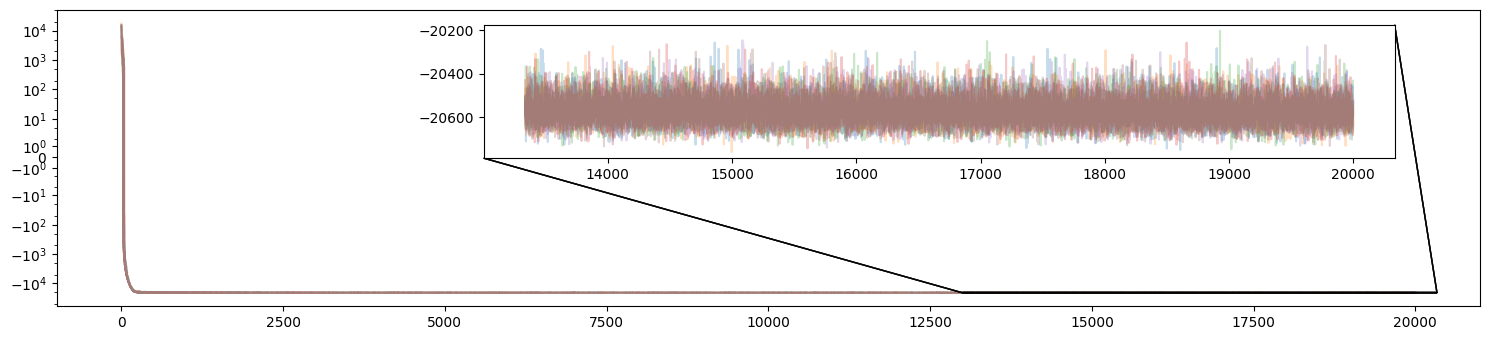

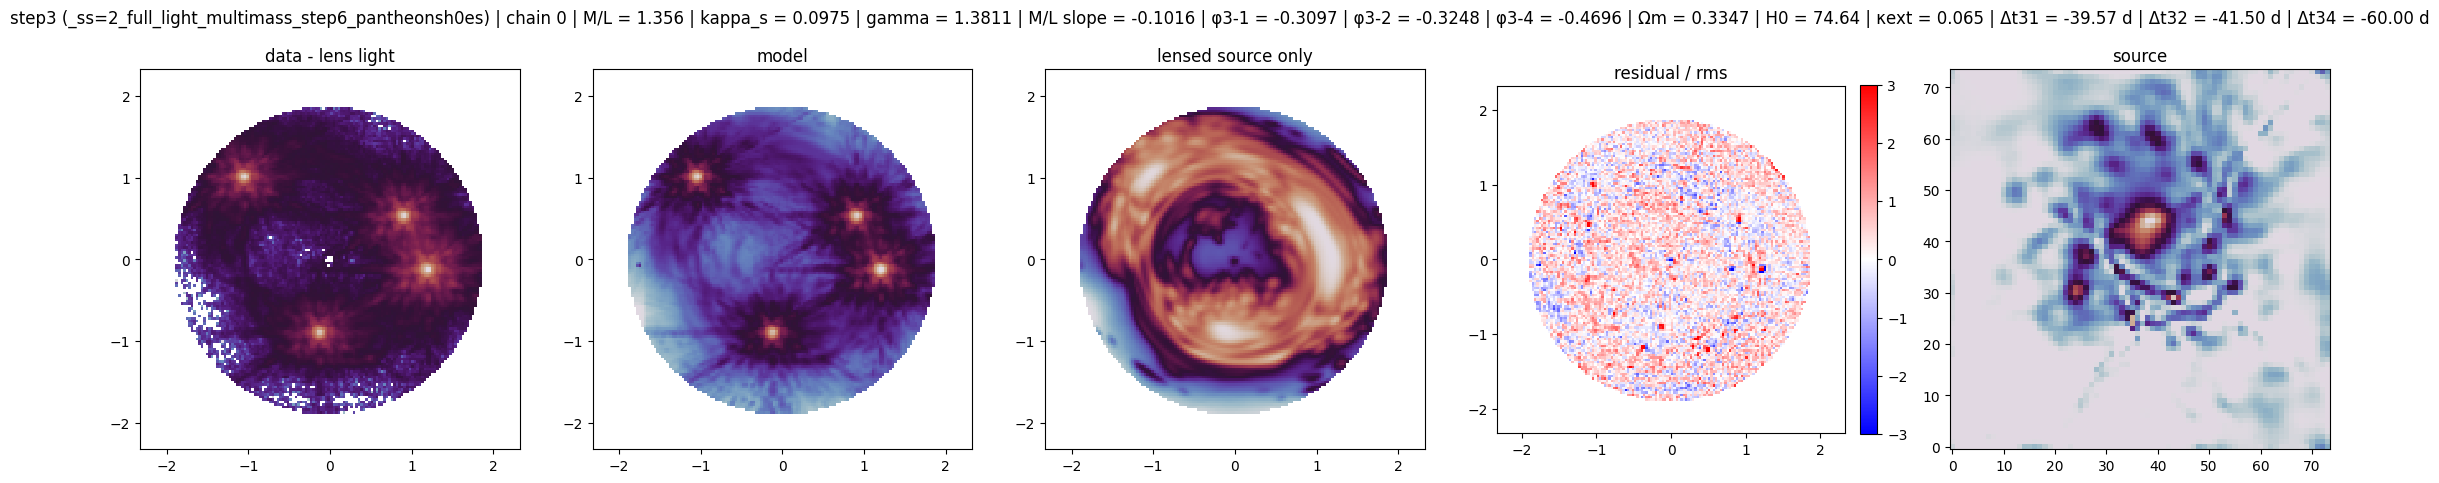

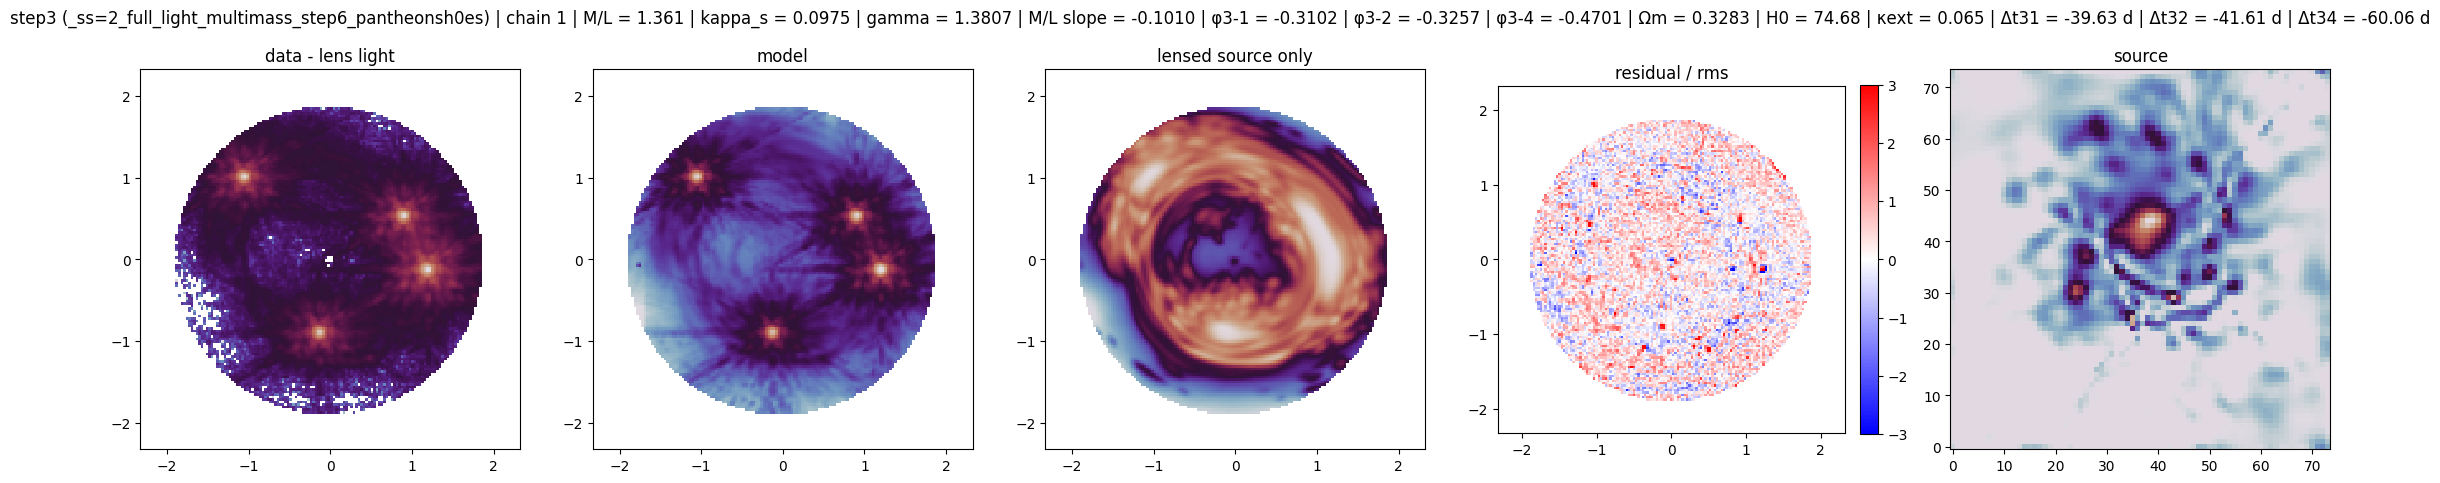

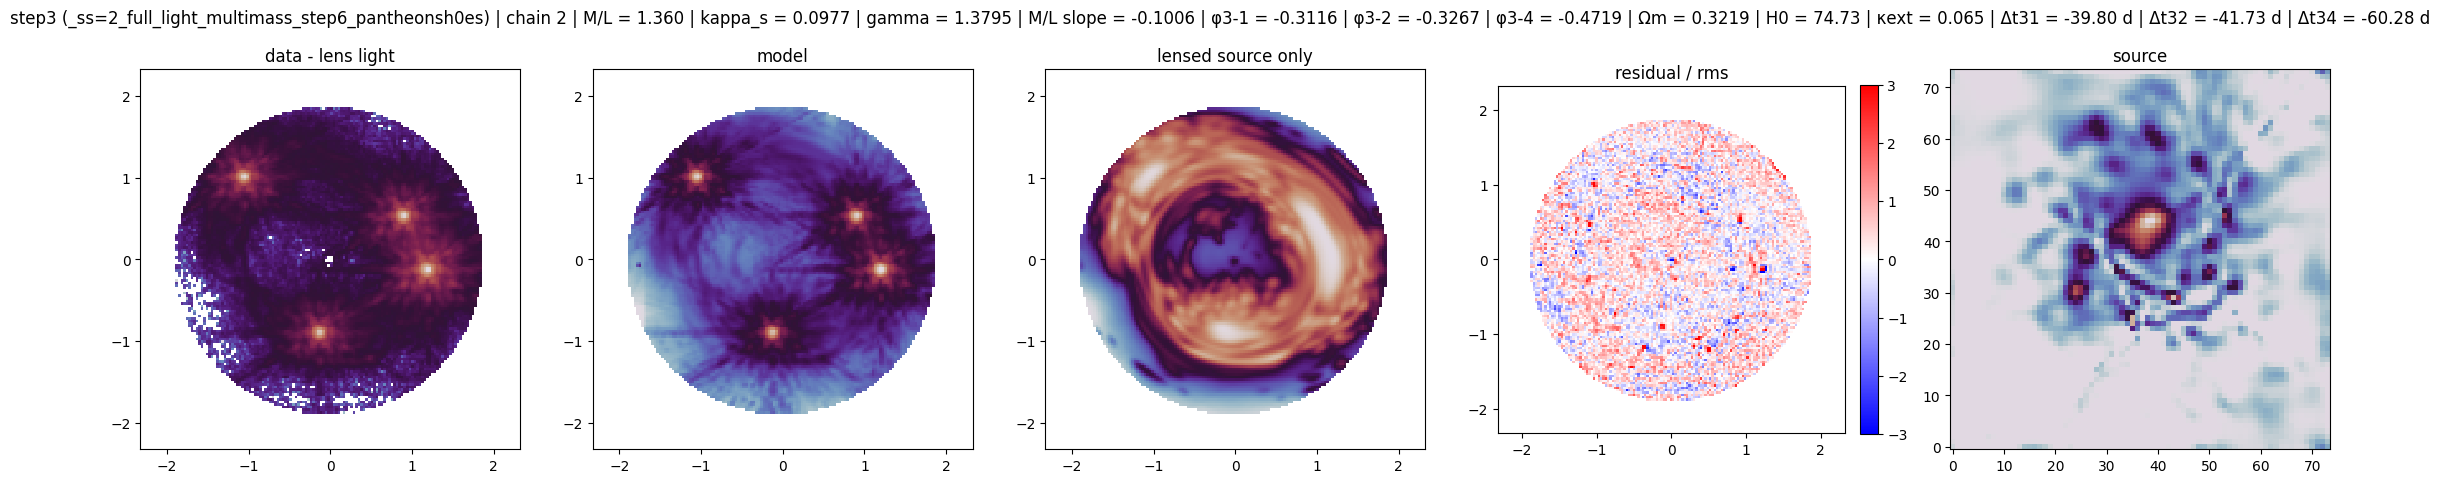

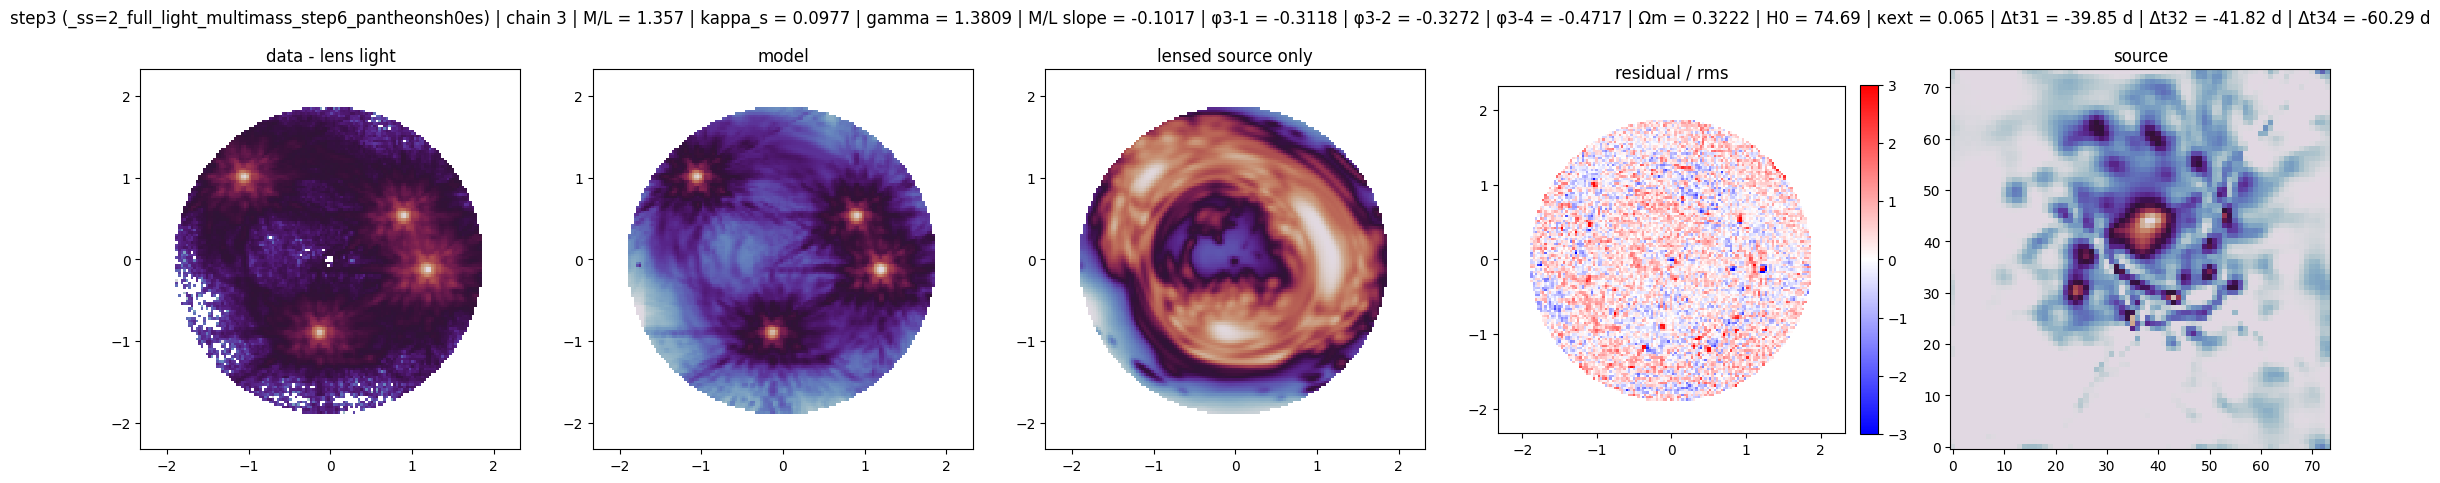

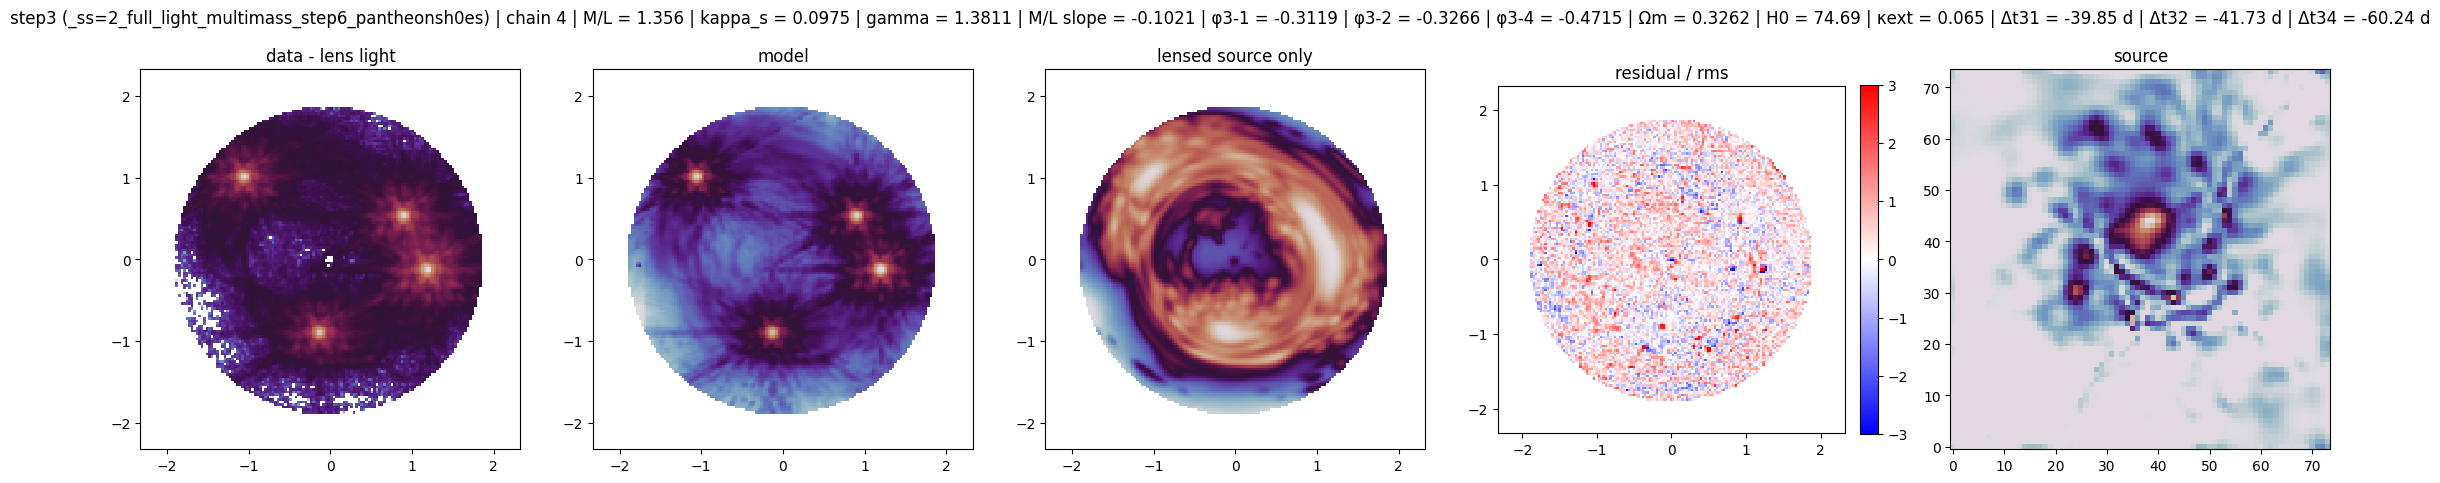

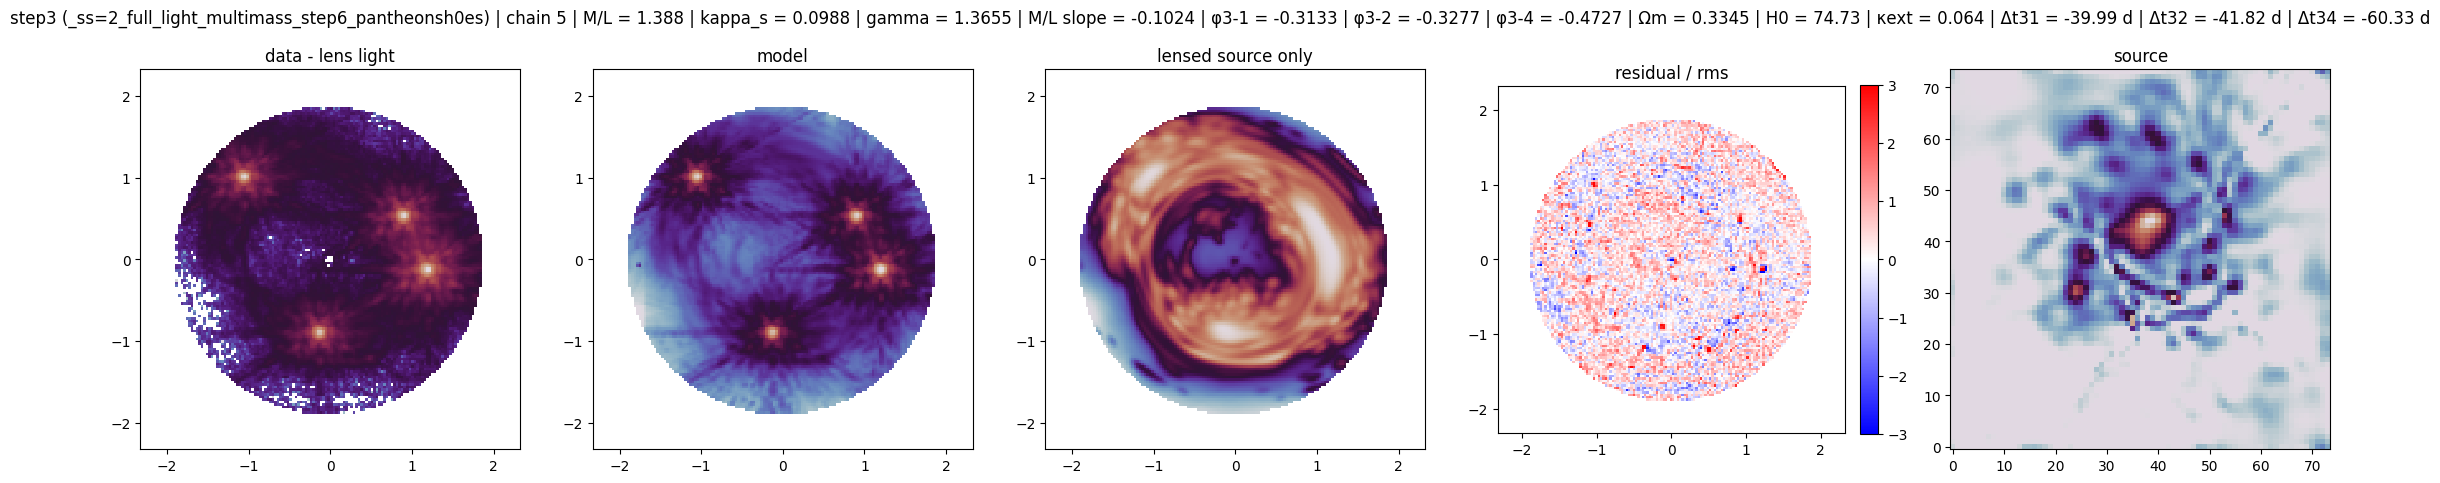

In [10]:
# STEP3_COSMO_PRIOR / STEP3_SUFFIX / STEP6_RESULT_DIR are defined above.

STEP3_KWARGS = {
    **STEP2_KWARGS,
    'label': f"step3 ({STEP3_SUFFIX})",
    'use_time_delay_likelihood': True,
    'cosmo_prior_name': STEP3_COSMO_PRIOR,
    'use_ml_gradient': True,
    'm2l_ratio_slope_low': -0.6,
    'm2l_ratio_slope_high': 0.6,
}


def build_step3_init_values(i):
    cosmo_prior = COSMO_PRIORS[STEP3_KWARGS['cosmo_prior_name']]
    return ResumeInit.select_init_values(step2_output['medians'][i], STEP2_LATENT_KEYS) | {
        'cosmo_vec': jnp.asarray(cosmo_prior['mean_vec'], dtype=jnp.float64),
        'kappa_ext': jnp.asarray(KAPPA_EXT_PRIOR['mean'], dtype=jnp.float64),
        'm2l_ratio_slope': jnp.asarray(0.0, dtype=jnp.float64),
    }


step3_output = run_stage(
    STEP3_KWARGS,
    init_builder=build_step3_init_values,
    max_iterations=20000,
    seed=3234,
)

plot_stage_losses(step3_output)
plot_stage_results(step3_output)


In [11]:
step1_medians = step1_output['medians']
step2_medians = step2_output['medians']
step3_medians = step3_output['medians']